# Initialization

In [2]:
import stim
import random
import csv
import pandas as pd
import collections
import os
import json
import numpy as np

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer

from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, Sampler, SamplerV2, RuntimeEncoder, RuntimeDecoder

from qiskit.visualization import plot_histogram, plot_circuit_layout, plot_state_city
from qiskit.circuit.classical import expr
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit
# from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay, PassManager
from qiskit.qasm2 import dumps
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from wrappers.polar_wrapper import (
        polar_code_p2, get_logical_error_on_accepted_states, divide_half_list
)

from wrappers.stim_wrapper import (
    convert_i_to_meas_type, generate_circuit_extraction_syndrome_stim, simulate_stim_polar_code, noisy_cx, noisy_h, noisy_x, noisy_z, 
    noisy_reset, noisy_measurement, calculate_logical_error_result_polar
    
)

from qiskit_ibm_runtime import QiskitRuntimeService

token = "IESwTaOxKx6Erz5OZ96Oj2wgr9DKnbiLQyCjYL3XQgnp"
QiskitRuntimeService.save_account(
    token=token,
    channel="ibm_quantum_platform",
    instance="free",
    set_as_default = True,
    overwrite=True
    )

service = QiskitRuntimeService()
# # QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
# # service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")

# # hw_name = "ibm_brisbane"
hw_name = "ibm_fez"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
    )


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

marker_map = {
        'x': 'o', 'z': 's', 
    }
marker_fill_map = {
        'x': 'full', 'z': 'none'
    }
linestyle_map = {
    "normal": '-', "m1": '-.', "m3": ':', 
    4: '-', 5: '-.', 6: ':', 7: '-.',
    "val": '-', "anqi": '-.'
}


CB_color_cycle_polar = ['#377eb8', '#ff7f00', '#4daf4a',
                '#f781bf', '#a65628', '#984ea3',
                "#7F4F4F", '#e41a1c', '#dede00']

In [4]:
# Helper function to get the correct error column name
def get_error_col(rate_col, df_cols):
    sem_col = f'{rate_col}_SEM'
    sd_col = f'{rate_col}_SD'
    if sem_col in df_cols:
        return sem_col
    elif sd_col in df_cols:
        return sd_col
    return None

# Normal - baseline

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
import numpy as np
import os
from matplotlib.ticker import MaxNLocator

def plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                      i_val, shots_val, decoder_val, hw_name=None,
                                ler_ylim_min=None, ler_ylim_max=None, number_below = False):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), including SEM/SD error bars and horizontal 
    baseline lines for the i=7 values.
    """
    df = pd.read_csv(file_path)

    combine_states = (lstate_val == 'combined')
    target_states = ['x', 'z'] if combine_states else [lstate_val]

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        (df['n'] == n_val) &
        (df['decoder_type'].isin(decoder_val)) &
        (df['lstate'].isin(target_states))
    ].copy()

    # --- Data Preparation ---
    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # Force integer type for 'i' immediately
    if 'i' in filtered_df.columns:
        filtered_df['i'] = filtered_df['i'].astype(int)
        
    # Get error columns
    prep_rate_error_col = get_error_col('prep_rate', filtered_df.columns)
    prep_rate_error_col = "prep_rate_SD"
    ler_error_col = get_error_col('LER', filtered_df.columns)

    if not prep_rate_error_col or not ler_error_col:
         print("Error: Could not find required error columns (_SEM or _SD).")
         return
    
    # 2c-2f. Prepare DataFrames for plotting
    pivot_df_prep_rate = filtered_df.pivot(index='i', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    pivot_df_prep_rate_err = filtered_df.pivot(index='i', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values='LER').sort_index(axis=1, ascending=False)
    pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)

    # --- 3. Plotting ---

    fig, ax1 = plt.subplots(figsize=(10, 5)) # Increased width slightly for text
    ax1.set_ylim(0, 1.1) # Increased top limit to make room for text above bars

    # Prep Rate Bar Plot (Primary Axis)
    prep_rate_error_values = pivot_df_prep_rate_err.values.T
    # print(prep_rate_error_values)

    # Note: plot(kind='bar') returns the Axes, not the container, but creates containers on ax1
    pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # LER Line Plot (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.set_yscale('log')
    if ler_ylim_min is not None or ler_ylim_max is not None:
        ax2.set_ylim(ler_ylim_min, ler_ylim_max)
    
    x_positions = ax1.get_xticks()
    ler_handles = []
    ler_colors = {'normal': '#2ca02c', 'm1': '#9467bd'}
    ler_markers = {'normal': 'o', 'm1': 's'}
    
    # --- NEW: Extract Baselines for Calculations ---
    baseline_lookup = {}
    baseline_df = filtered_df[filtered_df['i'] == 7]
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            baseline_lookup[row['sim_type']] = {
                'prep': row['prep_rate'],
                'ler': row['LER']
            }

    flag_better_ler = {}
    # Plot LER Lines and Annotate LER Points
    for idx, sim_type in enumerate(sim_type_val):
        if sim_type in pivot_df_ler.columns:
            ler_mean = pivot_df_ler[sim_type].values
            ler_err = pivot_df_ler_err[sim_type].values
            x_line_coords = x_positions
            
            ler_line, _, _ = ax2.errorbar(
                x_line_coords, 
                ler_mean,
                yerr=ler_err, 
                fmt=ler_markers.get(sim_type, 'o'), 
                color=ler_colors.get(sim_type, 'black'),
                linestyle='-',
                linewidth=2,
                capsize=3,
                zorder=3,
                label=f'LER ({sim_type.upper()})'
            )
            ler_handles.append(ler_line)

            # --- NEW: Annotate LER Percentages ---
            if sim_type in baseline_lookup:
                base_ler = baseline_lookup[sim_type]['ler']
                if base_ler > 0: # Avoid division by zero
                    for i_idx, val in enumerate(ler_mean):
                        # Skip annotating the baseline itself if you want (optional)
                        # if pivot_df_ler.index[i_idx] == 7: continue

                        pct_diff = ((val - base_ler) / base_ler) * 100
                        
                        # Logic: Lower LER is better (Green), Higher is worse (Red)
                        text_color = 'black' if pct_diff <= 0 else 'red'
                        sign = '-' if pct_diff < 0 else '+'

                        flag_better_ler[i_idx] = False

                        continue
                        # if pct_diff >= 0:
                        #     continue

                        flag_better_ler[i_idx] = True
                        
                        # Offset text slightly up in Log Scale (multiply, don't add)
                        ax2.text(
                            x_line_coords[i_idx], 
                            val * 0.35, 
                            f"{sign}{abs(pct_diff):.0f}%", 
                            color=text_color, 
                            ha='center', 
                            va='bottom', 
                            fontsize=9, 
                            # fontweight='bold'
                        )

    # --- NEW: Annotate Prep Rate Bars ---
    # ax1.containers contains the bars. 
    # Usually, they are in the order of the columns in pivot_df_prep_rate
    bar_cols = pivot_df_prep_rate.columns
    
    # We filter containers to only get BarContainers (exclude ErrorbarContainers)
    from matplotlib.container import BarContainer
    bar_containers = [c for c in ax1.containers if isinstance(c, BarContainer)]

    for idx, container in enumerate(bar_containers):
        if idx < len(bar_cols):
            sim_type = bar_cols[idx]
            if sim_type in baseline_lookup:
                base_prep = baseline_lookup[sim_type]['prep']
                
                # Loop through each bar in this group
                bar_idx = 0
                for rect, val in zip(container, pivot_df_prep_rate[sim_type]):
                    if base_prep > 0:
                        pct_diff = ((val - base_prep) / base_prep) * 100
                        
                        # Logic: Higher Prep is better (Green), Lower is worse (Red)
                        text_color = 'green' if pct_diff >= 0 else 'red'
                        sign = '+' if pct_diff >= 0 else '-'
                        
                        # if pct_diff <= 0:
                        #     continue

                    
                        # Calculate Y position (top of bar + small offset)
                        height = rect.get_height()
                        
                        text_pos = height + 0.02
                        if number_below:
                            text_pos = height + 0.02 + (0.14 * prep_rate_error_values[0][bar_idx] / max(prep_rate_error_values[0]))
                            text_color = 'green' if pct_diff >= 0 else 'red'

                            if bar_idx == 3:
                                text_pos = text_pos + 0.07

                        bar_idx = bar_idx + 1
                            
                        ax1.text(
                            rect.get_x() + rect.get_width() / 2, 
                            text_pos,  
                            # f"{sign}{abs(pct_diff):.1f}%", 
                            f"{sign}{abs(pct_diff):.0f}%", 
                            color=text_color, 
                            ha='center', 
                            va='bottom', 
                            fontsize=12, 
                            # fontweight='bold'
                        )

    # --- Draw Baseline Lines ---
    baseline_handles = []
    if not baseline_df.empty:
        print("Adding horizontal baseline lines for i=7 values.")
        for index, row in baseline_df.iterrows():
            sim_type = row['sim_type']
            
            # 1. Prep Rate Baseline
            prep_color = '#1f77b4' if sim_type == 'normal' else '#ff7f0e'
            prep_rate_line = ax1.axhline(
                y=row['prep_rate'],
                color=prep_color, 
                linestyle=':', 
                linewidth=1, 
                zorder=1,
                label='$p_{prep}$ baseline'
            )
            
            # 2. LER Baseline
            ler_color = ler_colors.get(sim_type, 'black')
            ler_line = ax2.axhline(
                y=row['LER'],
                color=ler_color, 
                linestyle='--', 
                linewidth=1, 
                zorder=1,
                label=f'LER baseline'
            )
            baseline_handles.append(prep_rate_line)
            baseline_handles.append(ler_line)


    # --- 4. Customizing Aesthetics and Legend ---

    ax1.set_xlabel('Information Position (i)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2.set_ylabel('Logical error rate (LER)', color=ler_colors['normal'])
    ax2.tick_params(axis='y', labelcolor=ler_colors['normal'])

    # Fix: Integer X-Labels
    ax1.set_xticklabels(pivot_df_prep_rate.index.astype(int), rotation=0)

    # Combine Legends
    # Get bar handles manually from the containers used for annotation
    bar_handles = [c[0] for c in bar_containers] 
    
    bar_labels = [
        # "$p_{prep}$ - prop-2" if l == 'm1' else "$p_{prep}$ - base"
        "$p_{prep}$ - prop-2" if l == 'm1' else "$p_{prep}$"
        for l in pivot_df_prep_rate.columns
    ]

    ler_labels = [
        # f"LER - prop-2" if l == 'm1' else f"LER - base"
        f"LER - prop-2" if l == 'm1' else f"LER"
        for l in pivot_df_ler.columns
    ]
    
    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + ler_labels

    ax1.legend(
        combined_handles,
        combined_labels,
        loc='upper left',
        fontsize=17
    )

    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False)

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

## Find Best position

Adding horizontal baseline lines for i=7 values.


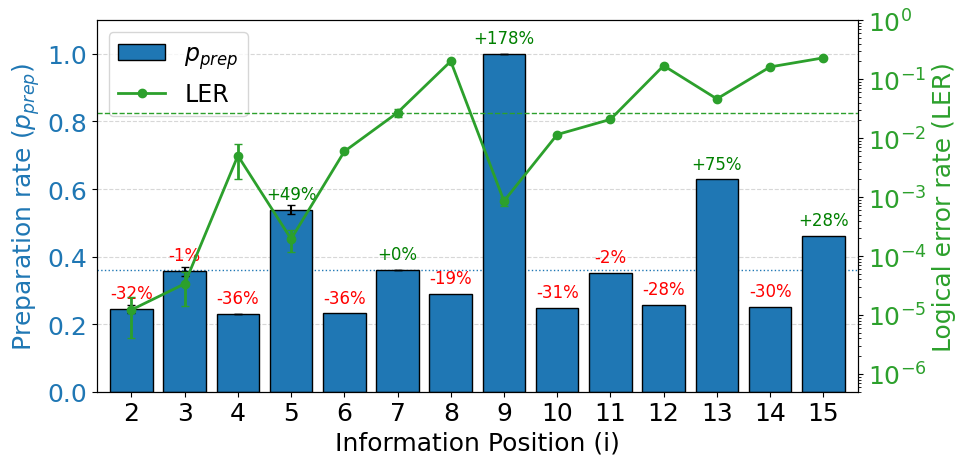

In [6]:
n_val = 4

# Result for the only accepted states
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n{n_val}_result/polar_results_json_normal_n{n_val}_combined.csv"
# file_path = f"./output/STIM/qiskit/ibm_torino_polar_results_json_qiskit_n5_combined.csv"
# file_path = f"./output/STIM/polar_results_json.csv"

# p_error_val = 0.005
p_error_val = 0.01
shots_val = 100

# p_error_val = 1

sim_type_val = ["normal"]
decoder_val = ["val"]
# i_val = [2, 3, 5, 9]
i_val = range(2, (2**n_val))
lstate_val = "x"

plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, decoder_val, ler_ylim_min=5e-7, ler_ylim_max=1e-0, number_below = False) # 0.005


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
import numpy as np
import os
from matplotlib.ticker import MaxNLocator
from matplotlib.container import BarContainer # Needed for BarContainer filtering

def plot_result_rate_profiling_normal_specific(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                      i_val, shots_val, decoder_val, hw_name=None,
                                ler_ylim_min=None, ler_ylim_max=None, number_below = False):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), with percentage comparison between sim_types.
    """
    df = pd.read_csv(file_path)

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        (df['n'] == n_val) &
        (df['decoder_type'].isin(decoder_val)) &
        # (df['comp_type'] == "na") &
        (df['lstate'] == lstate_val)
    ].copy()

    # --- Data Preparation ---
    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # Force integer type for 'i' immediately
    if 'i' in filtered_df.columns:
        filtered_df['i'] = filtered_df['i'].astype(int)
        
    # Get error columns
    # prep_rate_error_col = get_error_col('prep_rate', filtered_df.columns)
    prep_rate_error_col = "prep_rate_SD"
    # ler_error_col = get_error_col('LER', filtered_df.columns)
    ler_error_col = "LER_SD"

    if not prep_rate_error_col or not ler_error_col:
         print("Error: Could not find required error columns (_SEM or _SD).")
         return
    
    # 2c-2f. Prepare DataFrames for plotting
    pivot_df_prep_rate = filtered_df.pivot(index='i', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    pivot_df_prep_rate_err = filtered_df.pivot(index='i', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values='LER').sort_index(axis=1, ascending=False)
    pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)

    # --- 3. Plotting ---

    fig, ax1 = plt.subplots(figsize=(10, 5)) 
    # Adjusted Y-limit for annotation space
    ax1.set_ylim(0, 1.1) 

    # Prep Rate Bar Plot (Primary Axis)
    prep_rate_error_values = pivot_df_prep_rate_err.values.T

    # Plotting the bars
    pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # LER Line Plot (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.set_yscale('log')
    ax2.set_ylim(ler_ylim_min, ler_ylim_max) 
    
    x_positions = ax1.get_xticks()
    ler_handles = []
    ler_colors = {'normal': '#2ca02c', 'm1': '#9467bd'}
    ler_markers = {'normal': 'o', 'm1': 's'}
    
    # --- Plot LER Lines (Restored Logic) ---
    for idx, sim_type in enumerate(sim_type_val):
        if sim_type in pivot_df_ler.columns:
            ler_mean = pivot_df_ler[sim_type].values
            ler_err = pivot_df_ler_err[sim_type].values
            x_line_coords = x_positions
            
            ler_line, _, _ = ax2.errorbar(
                x_line_coords, 
                ler_mean,
                # yerr=ler_err, # Added yerr for LER plot
                fmt=ler_markers.get(sim_type, 'o'), 
                color=ler_colors.get(sim_type, 'black'),
                linestyle='-',
                linewidth=2,
                capsize=3,
                zorder=3,
                label=f'LER ({sim_type.upper()})'
            )
            ler_handles.append(ler_line)

    # --- ANNOTATE COMPARISON: prop-2 vs BASE ---

    # Get the BarContainers and Column names for comparison
    bar_containers = [c for c in ax1.containers if isinstance(c, BarContainer)]
    
    if len(pivot_df_prep_rate.columns) >= 2:
        # Assuming the columns are sorted as Base (C1) and prop-2 (C2)
        col_base = pivot_df_prep_rate.columns[0] 
        col_prop1 = pivot_df_prep_rate.columns[1] 
        
        if len(bar_containers) >= 2:
            # prop-2 bar container is the second container (index 1)
            container_prop1 = bar_containers[1] 
            
            # Loop through the data points using the index (i)
            bar_idx = 0
            for i_idx, i_val in enumerate(pivot_df_prep_rate.index):
                val_base = pivot_df_prep_rate.loc[i_val, col_base]
                val_prop1 = pivot_df_prep_rate.loc[i_val, col_prop1]
                
                if val_base > 0:
                    pct_diff = ((val_prop1 - val_base) / val_base) * 100
                    
                    # Logic: Higher Prep is better (Green), Lower is worse (Red)
                    text_color = 'green' if pct_diff >= 0 else 'red'
                    sign = '+' if pct_diff >= 0 else '-'
                    
                    # Get the rectangle (bar) corresponding to this data point (i_idx)
                    rect = container_prop1[i_idx]
                    height = rect.get_height()
                    text_pos = height + 0.02

                    if number_below:
                        text_pos = height + 0.02 + (0.14 * prep_rate_error_values[0][bar_idx] / max(prep_rate_error_values[0]))
                        text_color = 'green' if pct_diff >= 0 else 'red'

                        if bar_idx == 2:
                            text_pos = text_pos + 0.04

                    bar_idx = bar_idx + 1
                    
                    # Place text above the prop-2 bar
                    ax1.text(
                        rect.get_x() + rect.get_width() / 2, 
                        text_pos, # small offset
                        f"{sign}{abs(pct_diff):.1f}%", 
                        color=text_color, 
                        ha='center', 
                        va='bottom', 
                        fontsize=14, 
                        fontweight='bold',
                        zorder=4
                    )
    
    # --- Draw Baseline Lines (Restored Logic - assuming i=7 exists) ---
    baseline_df = filtered_df[filtered_df['i'] == 7]
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            sim_type = row['sim_type']
            
            # 1. Prep Rate Baseline
            prep_color = '#1f77b4' if sim_type == 'normal' else '#ff7f0e'
            ax1.axhline(
                y=row['prep_rate'],
                color=prep_color, 
                linestyle=':', 
                linewidth=0.8, 
                zorder=1,
                label='$p_{prep}$ baseline' # Note: label doesn't show in this setup
            )
            
            # 2. LER Baseline
            ler_color = ler_colors.get(sim_type, 'black')
            ax2.axhline(
                y=row['LER'],
                color=ler_color, 
                linestyle='--', 
                linewidth=0.8, 
                zorder=1,
                label=f'LER baseline' # Note: label doesn't show in this setup
            )

    # --- 4. Customizing Aesthetics and Legend ---

    ax1.set_xlabel('Information Position (i)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2.set_ylabel('Logical error rate (LER)', color=ler_colors['normal'])
    ax2.tick_params(axis='y', labelcolor=ler_colors['normal'])

    # Fix: Integer X-Labels
    ax1.set_xticklabels(pivot_df_prep_rate.index.astype(int), rotation=0)

    # Combine Legends
    bar_handles = [c[0] for c in bar_containers] 
    
    # Labels adjusted for comparison names
    bar_labels = [
        # "$p_{prep}$ - " + f"{l}"
        "$p_{prep}$ - prop-2" if l == 'm1' else "$p_{prep}$ - base"
        for l in pivot_df_prep_rate.columns
    ]

    ler_labels = [
        # f"LER - {l}"
        "LER - prop-2" if l == 'm1' else "LER - base"
        for l in pivot_df_ler.columns
    ]
    
    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + ler_labels

    ax1.legend(
        combined_handles,
        combined_labels,
        loc='upper right',
        fontsize=15
    )

    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False)

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

## Top 4 Position


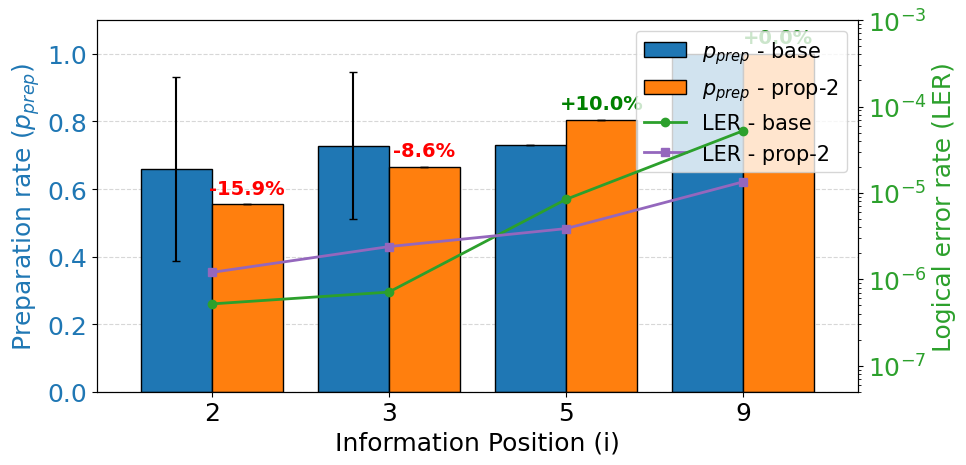

In [8]:
n_val = 4

# Result for the only accepted states
# file_path = f"./output/STIM/normal/polar_results_json_normal.csv"
file_path = f"./output/STIM/normal/n{n_val}_result/polar_results_json_normal_n{n_val}_combined.csv"
# file_path = f"./output/STIM/qiskit/ibm_torino_polar_results_json_qiskit_n5_combined.csv"
# file_path = f"./output/STIM/polar_results_json.csv"

# p_error_val = 0.005
p_error_val = 0.005
shots_val = 100

# p_error_val = 1

sim_type_val = ["normal", "m1"]
i_val = [2, 3, 5, 9]
lstate_val = "x"
# i_val = [8, 12, 14, 15]
# lstate_val = "z"
# decoder_val = ["anqi", "val"]
decoder_val = ["val"]

# plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.01
plot_result_rate_profiling_normal_specific(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, decoder_val, ler_ylim_min=5e-8, ler_ylim_max=1e-3) # 0.005
# plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=1e-7, ler_ylim_max=1e-3) # 0.005

In [21]:
import matplotlib.lines as mlines
def create_figure_peprep_accepted_normal(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        elif sim_type == "m3":
            str_sim_type = "prop-2"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'i = {i}'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['prep_rate'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-4
    x_max_limit = 1e-2
    y_min_limit = 0
    y_max_limit = 1.05

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower left',
        bbox_to_anchor=(0.01, 0.32),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Preparation Rate ($p_{prep}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peprep_n{n_values[0]}_{lstate_values[0]}.png')
    plt.show()

    return grouped

## Scale Prep Rate

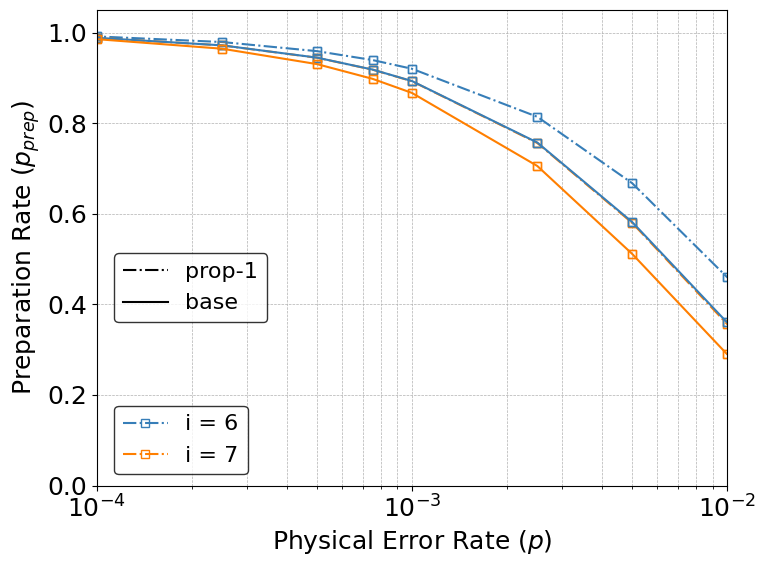

In [76]:
# --- Data Loading and Preparation (unchanged) ---
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["z"]

# n = [3]
# i_values = [4,5]
n = [4]
i_values = [6, 7]
sim_type_values = ["normal", "m1", "m3"]
# sim_type_values = ["normal", "m1"]

file_path = f"./output/STIM/clean/polar_results_json_normal_n{n[0]}_combined.csv"

grouped = create_figure_peprep_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/clean/")



In [28]:
grouped

### Scale Prep Rate with N and position from paper

In [146]:
import matplotlib.lines as mlines
def create_figure_peprep_accepted_normal_paper(df, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    # df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['i'].isin(i_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = n_values.index(n)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'N = {2**n}, i = {round(i)}'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['prep_rate'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-4
    x_max_limit = 1e-1
    y_min_limit = 0
    y_max_limit = 1.05

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower left',
        bbox_to_anchor=(0.01, 0.30),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Preparation Rate ($p_{prep}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peprep_{lstate_values[0]}_paper.png')
    plt.show()

In [147]:
import matplotlib.lines as mlines
def create_figure_peprep_accepted_normal_paper_sarteco(df, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    # df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['i'].isin(i_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = n_values.index(n)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'N = {2**n}, i = {round(i)}'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['prep_rate'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-4
    x_max_limit = 1e-2
    y_min_limit = 0
    y_max_limit = 1.05

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower left',
        bbox_to_anchor=(0.01, 0.26),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Tasa de error físico ($p$)')
    ax.set_ylabel('Tasa de preparación ($p_{prep}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peprep_{lstate_values[0]}_paper.png')
    plt.show()

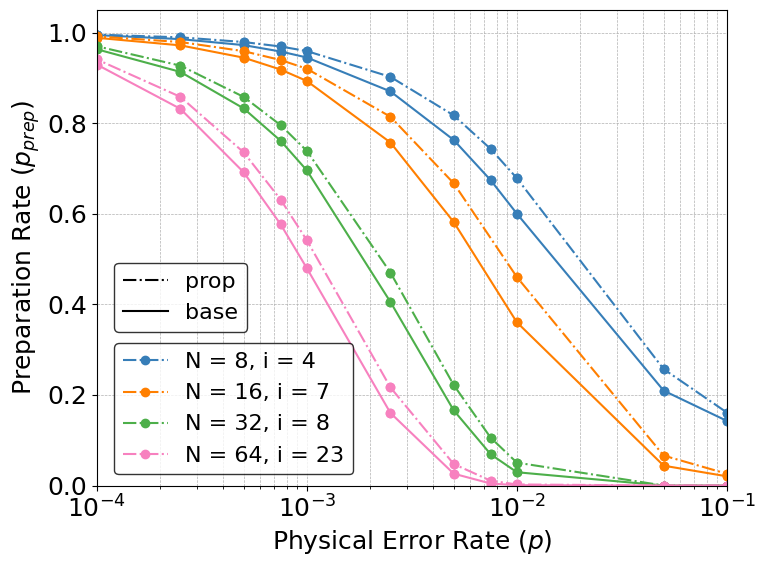

In [149]:
n = [3,4,5,6]
shots = 1000
lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
# lstate_values = ["z"]
i_values = [4, 7, 8, 23]
sim_type_values = ["normal", "m1"]

# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/clean/polar_results_json_normal_n3_combined.csv"
df_3 = pd.read_csv(file_path)

file_path = f"./output/STIM/clean/polar_results_json_normal_n4_combined.csv"
df_4 = pd.read_csv(file_path)

file_path = f"./output/STIM/clean/polar_results_json_normal_n5_combined.csv"
df_5 = pd.read_csv(file_path)

file_path = f"./output/STIM/clean/polar_results_json_normal_n6_combined.csv"
df_6 = pd.read_csv(file_path)

df_combined = pd.concat([df_3, df_4, df_5, df_6], axis=0, ignore_index=True, sort=False)

conditions = (
    ((df_combined['n'] == 3) & (df_combined['i'] == 4)) |
    ((df_combined['n'] == 4) & (df_combined['i'] == 7)) |
    ((df_combined['n'] == 5) & (df_combined['i'] == 8)) |
    ((df_combined['n'] == 6) & (df_combined['i'] == 23))
)

# Apply the combined filter
filtered_df = df_combined[
    conditions &
    (df_combined['lstate'].isin(lstate_values)) &
    (df_combined['sim_type'].isin(sim_type_values))
].copy()

# # Check the result
# filtered_df[filtered_df["n"] == 4]



create_figure_peprep_accepted_normal_paper(filtered_df, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/clean/")

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.lines as mlines

def create_figure_peler_accepted_normal(file_path, n_values, lstate_values, shots, i_values, sim_type_values, decoder_type_val, y_label, out_path="peprep_plot.png"):

    # --- Data Loading and Filtering ---
    df = pd.read_csv(file_path)
    
    if not isinstance(n_values, list):
        n_values = [n_values]
        
    if not isinstance(lstate_values, list):
        lstate_values = [lstate_values]

    # Check if we are performing a combined X + Z calculation
    combine_states = 'combined' in lstate_values
    filter_lstates = ['x', 'z'] if combine_states else lstate_values

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(filter_lstates)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['decoder_type'].isin(decoder_type_val)) &
        (df['p_error'] != 0.0005) &
        (df['p_error'] != 0.00075) &
        (df['p_error'] != 0.00025) &
        (df['p_error'] != 0.0001) &
        # (df['p_error'] != 0.1) &
        # (df['p_error'] != 0.05) &
        (df['LER'] != 0)
    ].copy()

    # --- Intercept and Combine 'x' and 'z' States ---
    if combine_states:
        print("masuk combined states")
        group_cols = ['n', 'sim_type', 'i', 'p_error', 'decoder_type']
        
        # Dynamically include error columns if they exist in the raw CSV
        val_cols = [y_label]
        for ec in [f'{y_label}_SD', f'{y_label}_SEM']:
            if ec in filtered_df.columns:
                val_cols.append(ec)
                
        # Pivot X and Z columns side by side per parameter set
        pivot_combined = filtered_df.pivot_table(
            index=group_cols,
            columns='lstate',
            values=val_cols
        ).reset_index()
        
        # Flatten MultiIndex columns safely: ('LER', 'x') -> 'LER_x'
        pivot_combined.columns = [
            f"{col[0]}_{col[1]}" if col[1] else col[0] 
            for col in pivot_combined.columns
        ]
        
        # Calculate combined LER metric
        pivot_combined[y_label] = 1 - ((1 - pivot_combined[f'{y_label}_x']) * (1 - pivot_combined[f'{y_label}_z']))
        
        # Optional: Propagate error metrics if you ever upgrade this function to use errorbar
        if f'{y_label}_SD_x' in pivot_combined.columns and f'{y_label}_SD_z' in pivot_combined.columns:
            pivot_combined[f'{y_label}_SD'] = (1 - pivot_combined[y_label]) * np.sqrt(
                (pivot_combined[f'{y_label}_SD_x'] / (1 - pivot_combined[f'{y_label}_x'])).fillna(0)**2 +
                (pivot_combined[f'{y_label}_SD_z'] / (1 - pivot_combined[f'{y_label}_z'])).fillna(0)**2
            )
        if f'{y_label}_SEM_x' in pivot_combined.columns and f'{y_label}_SEM_z' in pivot_combined.columns:
            pivot_combined[f'{y_label}_SEM'] = (1 - pivot_combined[y_label]) * np.sqrt(
                (pivot_combined[f'{y_label}_SEM_x'] / (1 - pivot_combined[f'{y_label}_x'])).fillna(0)**2 +
                (pivot_combined[f'{y_label}_SEM_z'] / (1 - pivot_combined[f'{y_label}_z'])).fillna(0)**2
            )
            
        # Force string assignment so downstream grouping behaves correctly
        pivot_combined['lstate'] = 'combined'
        filtered_df = pivot_combined

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---
    plt.figure(figsize=(8, 6))
    ax = plt.gca() 

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'i'])
    
    data_handles = []
    data_labels = []
    sim_type_proxies = {} 

    # 2. Iterate through each group and plot it
    for (n, sim_type, i), group_df in grouped:
        print("Sim Type: ", n, sim_type, i)
        lstate = "x"
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, '-') 
        
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx % len(CB_color_cycle_polar)]

        if lstate == "x":
            str_log = "|+>"
        elif lstate == "z":
            str_log = "|0>"
        else:
            str_log = "Combined"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        elif sim_type == "m3":
            str_sim_type = "prop-2"
        else:
            str_sim_type = "base"

        data_label = f'i = {i}'
        
        # Plot the data using unified parameters
        line, = ax.loglog(
            group_df['p_error'],
            group_df[y_label],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' 
        )
        
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        if str_sim_type not in sim_type_proxies:
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Graph Boundaries
    x_min_limit = 5e-4
    x_max_limit = 1e-1
    y_min_limit = 1e-8
    y_max_limit = 1e-0

    # 4. Create and Place Legends
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=15
    )
    ax.add_artist(legend1)

    legend2 = ax.legend(
        data_handles,
        data_labels,
        loc='lower right',
        bbox_to_anchor=(1, 0), 
        frameon=True,
        edgecolor='black',
        fontsize=15
    )
    
    # --- Remaining Plot Styling ---
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Logical Error Rate (LER)')
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    plt.tight_layout()

    # Save the figure securely
    plt.savefig(f'{out_path}baseline_polar_pe{y_label}_{decoder_type_val[0]}_n{n}_all.png')
    plt.show()

    return grouped

## Scale LER

Sim Type:  4 m1 6
Sim Type:  4 m1 7
Sim Type:  4 m3 6
Sim Type:  4 normal 6
Sim Type:  4 normal 7


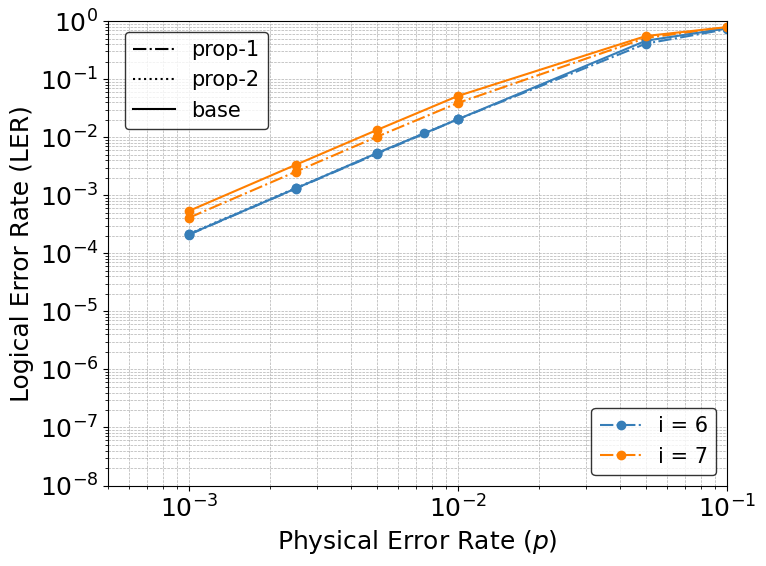

In [80]:
file_path = f"./output/STIM/clean/polar_results_json_normal_n4_combined.csv"
n = [4]
# shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["x"]
# i_values = [6,7,10]
i_values = [6,7]
sim_type_values = ["normal","m1","m3"]
decoder_type_val = ["val"]
y_label = "LER_undecided"

grouped = create_figure_peler_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, decoder_type_val, y_label, out_path="./output/STIM/clean/")



### by Decoder Type

In [41]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_normal_by_decoder_type(file_path, n_values, lstate_values, shots, i_values, sim_type_values, decoder_type_val, out_path="peprep_plot.png", exp_type = None):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['decoder_type'].isin(decoder_type_val)) &
        (df['p_error'] != 0.0005) &
        (df['p_error'] != 0.1) &
        (df['p_error'] != 0.05) &
        (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', "sim_type", 'decoder_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    dec_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, decoder_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(decoder_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if decoder_type == "anqi":
            str_dec_type = "anqi"
        else:
            str_dec_type = "val"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'i = {i}'
        
        # Plot the data
        line, = ax.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_dec_type not in dec_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_dec_type)
            dec_type_proxies[str_dec_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 5e-4
    x_max_limit = 1e-2
    y_min_limit = 1e-12
    y_max_limit = 1e-3

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(dec_type_proxies.values())
    sim_labels = list(dec_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=15
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower right',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(1, 0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=15
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Logical Error Rate (LER)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    print(sim_type_val)
    if exp_type == "cc":
        plt.savefig(f'{out_path}baseline_polar_peler_codecap_{sim_type_values[0]}_n{n}_{lstate_values[0]}.png')
    else:
        plt.savefig(f'{out_path}baseline_polar_peler_{sim_type_values[0]}_n{n}_{lstate_values[0]}.png')
    plt.show()

['normal', 'm1']


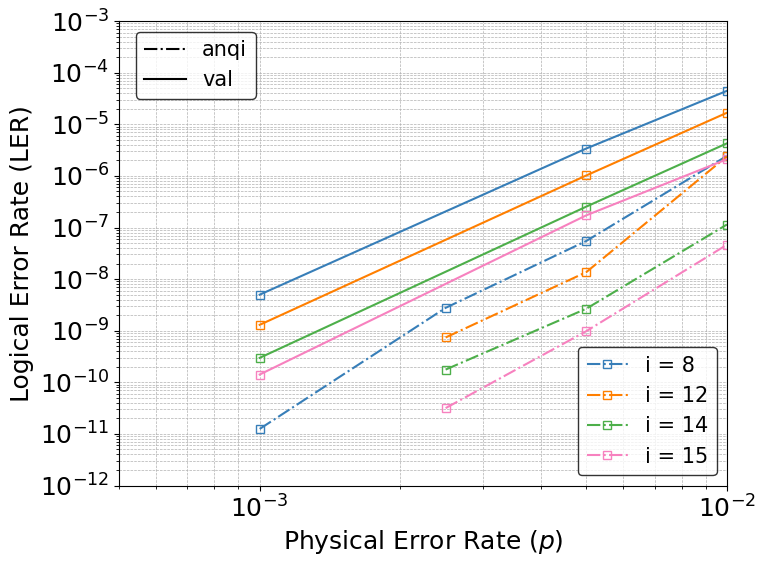

In [42]:
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
n = [4]
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["z"]
i_values = [8, 12, 14, 15]
# sim_type_values = ["normal", "m1"]
sim_type_values = ["m1"]
decoder_type_val = ["val", "anqi"]

create_figure_peler_accepted_normal_by_decoder_type(file_path, n, lstate_values, shots, i_values, sim_type_values, decoder_type_val, out_path="./output/STIM/normal/")



['normal', 'm1']


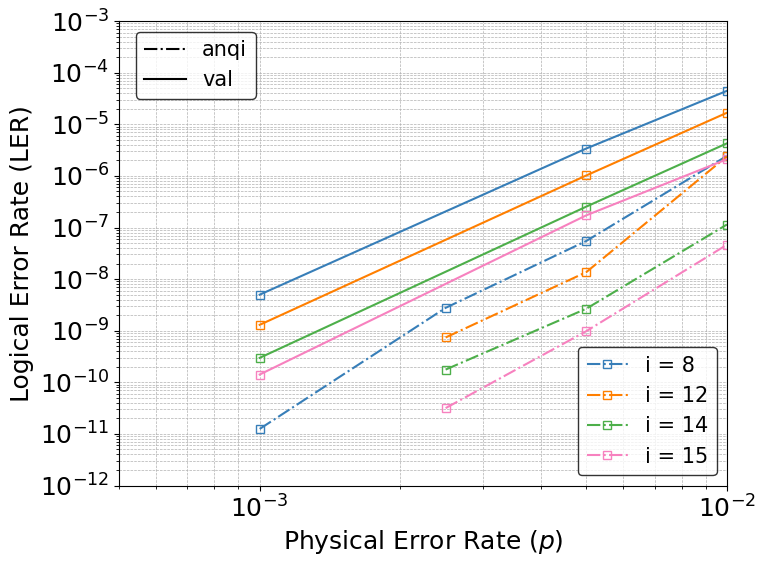

In [43]:
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
n = [4]
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["z"]
i_values = [8, 12, 14, 15]
# sim_type_values = ["normal", "m1"]
sim_type_values = ["m1"]
decoder_type_val = ["val", "anqi"]

create_figure_peler_accepted_normal_by_decoder_type(file_path, n, lstate_values, shots, i_values, sim_type_values, decoder_type_val, out_path="./output/STIM/normal/")



### Code Cap

In [44]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_normal_by_cc(file_path, n_values, lstate_values, shots, i_values, sim_type_values, decoder_type_val, out_path="peprep_plot.png", exp_type = None):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['decoder_type'].isin(decoder_type_val)) &
        (df['p_error'] != 0.0005) &
        (df['p_error'] != 0.1) &
        (df['p_error'] != 0.05) &
        (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', "sim_type", 'decoder_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    dec_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, decoder_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(decoder_type, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if decoder_type == "anqi":
            str_dec_type = "anqi"
        else:
            str_dec_type = "val"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'i = {i}'
        
        # Plot the data
        line, = ax.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_dec_type not in dec_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_dec_type)
            dec_type_proxies[str_dec_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 4e-2
    x_max_limit = 1e-1
    y_min_limit = 1e-7
    y_max_limit = 1e-1

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(dec_type_proxies.values())
    sim_labels = list(dec_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=15
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower right',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(1, 0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=15
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Logical Error Rate (LER)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    print(sim_type_val)
    if exp_type == "cc":
        plt.savefig(f'{out_path}baseline_polar_peler_codecap_{sim_type_values[0]}_n{n}_{lstate_values[0]}.png')
    else:
        plt.savefig(f'{out_path}baseline_polar_peler_{sim_type_values[0]}_n{n}_{lstate_values[0]}.png')
    plt.show()

['normal', 'm1']


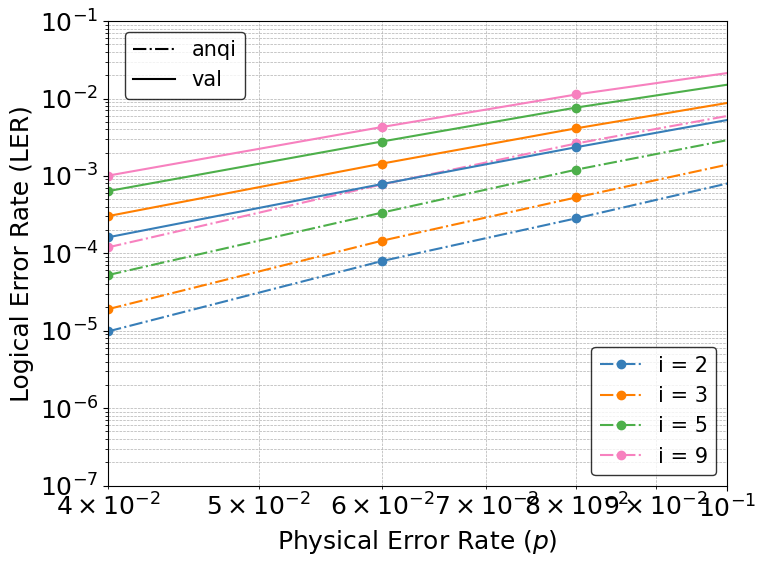

In [45]:
file_path = f"./output/STIM/normal/n4_result_code_cap/polar_results_json_normal_codecap_n4_combined.csv"
n = [4]
shots = 1000
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
# lstate_values = ["z"]
# i_values = [8, 12, 14, 15]
# sim_type_values = ["normal", "m1"]
sim_type_values = ["m1"]
decoder_type_val = ["val", "anqi"]

create_figure_peler_accepted_normal_by_cc(file_path, n, lstate_values, shots, i_values, sim_type_values, decoder_type_val, out_path="./output/STIM/normal/", exp_type = "cc")



### Scale LER with N and position from valentin paper

In [150]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_normal_paper(df, n_values, lstate_values, shots, i_values, sim_type_values, y_label, decoder_type, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    # df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['i'].isin(i_values)) &
        # (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['p_error'] != 0.0005) &
        (df['p_error'] != 0.0001) &
        (df['p_error'] != 0.00025) &
        (df['p_error'] != 0.00075) &
        (df[y_label] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, i), group_df in grouped:
        lstate = 'x' 
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = n_values.index(n)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'N = {2**n}, i = {round(i)}'
        
        # Plot the data
        line, = ax.loglog(
            group_df['p_error'],
            group_df[y_label],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 5e-4
    x_max_limit = 1e-1
    y_min_limit = 1e-8
    y_max_limit = 1

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower right',
        bbox_to_anchor=(1, 0.30),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower right',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(1, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Logical Error Rate (LER)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_pe{y_label}_{decoder_type}_all_paper.png')
    plt.show()

In [151]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_normal_paper_sarteco(df, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    # df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['i'].isin(i_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['sim_type'].isin(sim_type_values)) &
        # (df['p_error'] != 0.0005) &
        # (df['p_error'] != 0.0001) &
        # (df['p_error'] != 0.00025) &
        # (df['p_error'] != 0.00075) &
        (df['decoder_type'] != "anqi") &
        (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = n_values.index(n)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'N = {2**n}, i = {round(i)}'
        
        # Plot the data
        line, = ax.loglog(
            group_df['p_error'],
            group_df['LER'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 5e-4
    x_max_limit = 1e-2
    y_min_limit = 1e-8
    y_max_limit = 1e-1

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower right',
        bbox_to_anchor=(1, 0.23),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower right',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(1, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Tasa de error físico ($p$)')
    ax.set_ylabel('Tasa de error lógico (LER)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peler_{lstate_values[0]}_paper.png')
    plt.show()

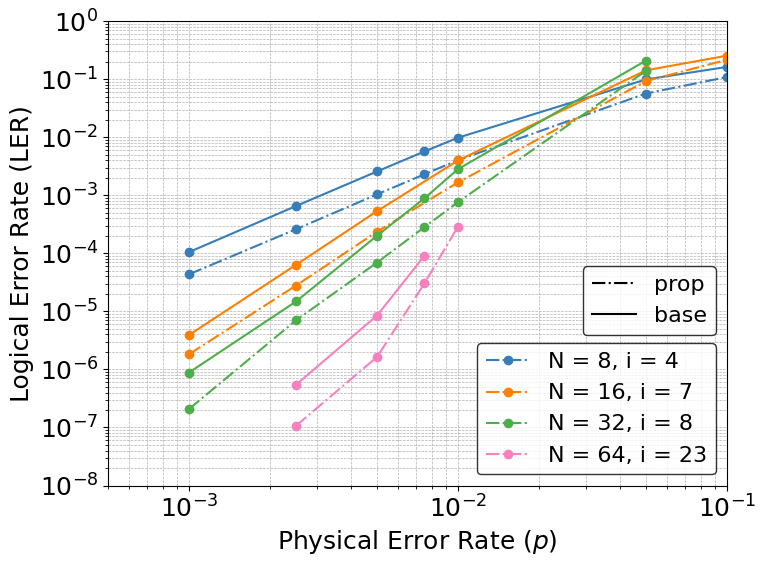

In [153]:
n = [3,4,5,6]
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["x"]
i_values = [4, 7, 8, 23]
sim_type_values = ["normal", "m1"]
dec_type_values = ["val"]

group_cols = ['n', 'i', 'p_error', 'sim_type', 'decoder_type']
y_label = 'LER_error'
# y_label = 'LER_undecided'

# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/clean/polar_results_json_normal_n3_combined.csv"
df_3 = pd.read_csv(file_path)
pdf_3 = df_3.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_3[y_label] = 1 - ((1 - pdf_3['x']) * (1 - pdf_3['z']))


file_path = f"./output/STIM/clean/polar_results_json_normal_n4_combined.csv"
df_4 = pd.read_csv(file_path)
pdf_4 = df_4.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_4[y_label] = 1 - ((1 - pdf_4['x']) * (1 - pdf_4['z']))

file_path = f"./output/STIM/clean/polar_results_json_normal_n5_combined.csv"
df_5 = pd.read_csv(file_path)
pdf_5 = df_5.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_5[y_label] = 1 - ((1 - pdf_5['x']) * (1 - pdf_5['z']))

file_path = f"./output/STIM/clean/polar_results_json_normal_n6_combined.csv"
df_6 = pd.read_csv(file_path)
pdf_6 = df_6.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_6[y_label] = 1 - ((1 - pdf_6['x']) * (1 - pdf_6['z']))

df_combined = pd.concat([pdf_3, pdf_4, pdf_5, pdf_6], axis=0, ignore_index=True, sort=False)

conditions = (
    ((df_combined['n'] == 3) & (df_combined['i'] == 4)) |
    ((df_combined['n'] == 4) & (df_combined['i'] == 7)) |
    ((df_combined['n'] == 5) & (df_combined['i'] == 8)) |
    ((df_combined['n'] == 6) & (df_combined['i'] == 23))
)

# conditions = (
#     ((df_combined['n'] == 4) & (df_combined['i'] == 4)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 6)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 7)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 10)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 11)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 13))
# )

# Apply the combined filter
filtered_df = df_combined[
    conditions &
    # (df_combined['lstate'].isin(lstate_values)) &
    (df_combined['sim_type'].isin(sim_type_values)) &
    (df_combined['decoder_type'].isin(dec_type_values)) 
].copy()

# # Check the result
# filtered_df[filtered_df["n"] == 4]



create_figure_peler_accepted_normal_paper(filtered_df, n, lstate_values, shots, i_values, sim_type_values, y_label,dec_type_values[0], out_path="./output/STIM/clean/")

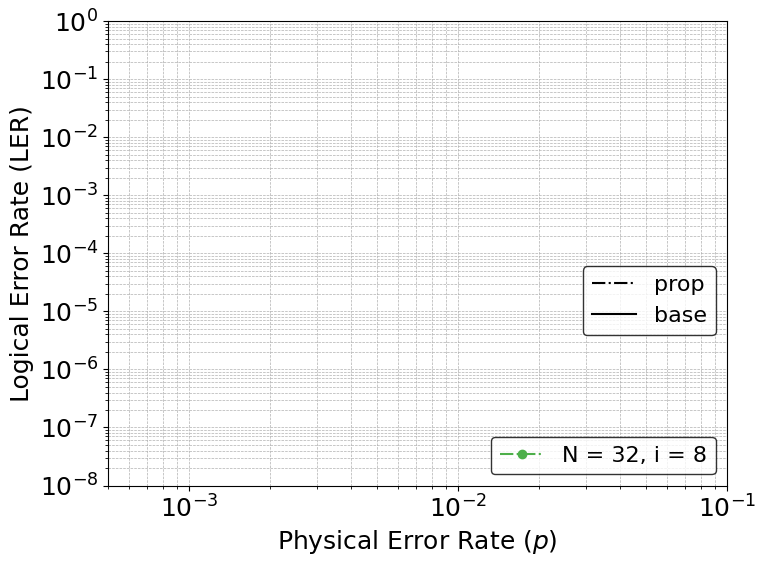

In [55]:
n = [3,4,5,6]
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["x"]
i_values = [4, 7, 8, 23]
sim_type_values = ["normal", "m1"]
dec_type_values = ["anqi"]

group_cols = ['n', 'i', 'p_error', 'sim_type', 'decoder_type']
# y_label = 'LER_error'
y_label = 'LER_undecided'

# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/clean/polar_results_json_normal_n3_combined.csv"
df_3 = pd.read_csv(file_path)
pdf_3 = df_3.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_3[y_label] = 1 - ((1 - pdf_3['x']) * (1 - pdf_3['z']))


file_path = f"./output/STIM/clean/polar_results_json_normal_n4_combined.csv"
df_4 = pd.read_csv(file_path)
pdf_4 = df_4.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_4[y_label] = 1 - ((1 - pdf_4['x']) * (1 - pdf_4['z']))

file_path = f"./output/STIM/clean/polar_results_json_normal_n5_combined.csv"
df_5 = pd.read_csv(file_path)
pdf_5 = df_5.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_5[y_label] = 1 - ((1 - pdf_5['x']) * (1 - pdf_5['z']))

file_path = f"./output/STIM/clean/polar_results_json_normal_n6_combined.csv"
df_6 = pd.read_csv(file_path)
pdf_6 = df_6.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_6[y_label] = 1 - ((1 - pdf_6['x']) * (1 - pdf_6['z']))

df_combined = pd.concat([pdf_3, pdf_4, pdf_5, pdf_6], axis=0, ignore_index=True, sort=False)

conditions = (
    ((df_combined['n'] == 3) & (df_combined['i'] == 4)) |
    ((df_combined['n'] == 4) & (df_combined['i'] == 7)) |
    ((df_combined['n'] == 5) & (df_combined['i'] == 8)) |
    ((df_combined['n'] == 6) & (df_combined['i'] == 23))
)

# Apply the combined filter
filtered_df = df_combined[
    conditions &
    # (df_combined['lstate'].isin(lstate_values)) &
    (df_combined['sim_type'].isin(sim_type_values)) &
    (df_combined['decoder_type'].isin(dec_type_values)) 
].copy()

# # Check the result
# filtered_df[filtered_df["n"] == 4]



create_figure_peler_accepted_normal_paper(filtered_df, n, lstate_values, shots, i_values, sim_type_values, y_label,dec_type_values[0], out_path="./output/STIM/clean/")

## Scale Cost (Prop-3)

In [25]:
import matplotlib.lines as mlines
def create_figure_pecost_accepted_normal(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    df["cost_save"] = 1 - df["cost"]

    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        ~((df['n'] == 4) & (df['i'] == 9))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(7, 5))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        # linestyle = linestyle_map.get(sim_type, 'm1') 
        linestyle = linestyle_map.get(n, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        # if sim_type == "m1":
        #     str_sim_type = "prop-2"
        # elif sim_type == "m2":
        #     str_sim_type = "prop-3"
        # else:
        #     str_sim_type = "base"

        str_sim_type = f"N = {pow(2,n)}"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'i = {i}'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['cost_save'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 1e-4
    x_max_limit = 1e-2
    y_min_limit = -0.01
    y_max_limit = 0.35

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='upper left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.80), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Resource Saving ($\eta_{\mathrm{save}}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_pecost_n{n}_{lstate_values[0]}.png')
    plt.show()

<>:140: SyntaxWarning: invalid escape sequence '\e'
<>:140: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3407320/1449469902.py:140: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('Resource Saving ($\eta_{\mathrm{save}}$)')


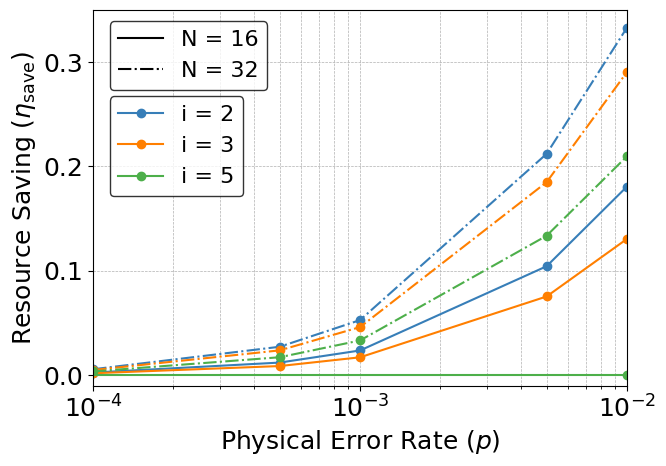

In [26]:
# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
n = [4, 5]
shots = 1000
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
sim_type_values = ["m2"]

create_figure_pecost_accepted_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")



## Pareto Plot

In [27]:
import numpy as np

def format_to_mathtext(number: float, precision: int = 1) -> str:
    """
    Converts a float to a scientific notation string formatted for Matplotlib's Mathtext (e.g., 10^{-3}).
    
    Args:
        number: The float value to format.
        precision: The number of digits after the decimal point for the coefficient.
        
    Returns:
        A string formatted for Matplotlib/LaTeX rendering.
    """
    # 1. Convert to standard scientific notation (e.g., '1.0e-03')
    # Use f-string formatting with 'e' specifier
    s_standard = f'{number:.{precision}e}'
    
    # 2. Split the coefficient and the exponent
    # Example: '1.0e-03' -> ['1.0', '-03']
    if 'e' in s_standard:
        coefficient, exponent = s_standard.split('e')
    elif 'E' in s_standard:
        coefficient, exponent = s_standard.split('E')
    else:
        # If the number is zero or already formatted without an exponent
        return f'${s_standard}$' 

    # 3. Format the exponent for Mathtext: remove sign if it's '+' and remove leading zeros
    exponent_val = int(exponent)
    
    # 4. Combine the parts into the desired format ($coefficient \times 10^{exponent}$)
    # Note: Use '\times' for the multiplication symbol and '{}' for the superscript.
    
    if exponent_val == 0:
        # If exponent is 0, just show the coefficient
        return f'${coefficient}$'
    elif coefficient == '1' or coefficient == '1.0':
        # Simplify if the coefficient is 1 (e.g., just $10^{-3}$)
        return f'$10^{{{exponent_val}}}$'
    else:
        # Full format: $C \times 10^{E}$
        return f'${coefficient} \\times 10^{{{exponent_val}}}$'


# --- Examples ---
print(f"1e-3 (1e-3) -> {format_to_mathtext(1e-3)}")        # Output: $10^{-3}$
print(f"5.2e-6 (0.0000052) -> {format_to_mathtext(5.2e-6, 1)}") # Output: $5.2 \times 10^{-6}$
print(f"12000 (1.2e+04) -> {format_to_mathtext(12000, 1)}") # Output: $1.2 \times 10^{4}$
print(f"1.0 (1.0) -> {format_to_mathtext(1.0, 1)}")        # Output: $1.0$
print(f"0.00000000321 (3.21e-09) -> {format_to_mathtext(3.21e-09, 2)}") # Output: $3.21 \times 10^{-9}$

1e-3 (1e-3) -> $10^{-3}$
5.2e-6 (0.0000052) -> $5.2 \times 10^{-6}$
12000 (1.2e+04) -> $1.2 \times 10^{4}$
1.0 (1.0) -> $1.0$
0.00000000321 (3.21e-09) -> $3.21 \times 10^{-9}$


In [28]:
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from typing import List, Dict, Any

# --- Mapping Dictionaries (Improvised based on your style) ---
# Assuming 'label' is in the format 'simtype_i#' (e.g., 'base_i2')

# Map the simulation type from the label to a marker style
MARKER_MAP_PARETO = {"normal": "o", "m1": "s"}

# Map the iteration number ('i#') from the label to a color
# Using standard matplotlib color cycle for simplicity, similar to CB_color_cycle_polar usage
COLOR_MAP_PARETO = {
    2: "C0",
    3: "C1",
    5: "C2",
    9: "C3",
    17: "C4",
    8: "C5",
    12: "C6",
    14: "C7",
    15: "C8",
}

LINESTYLE_MAP_PARETO = {
    "all-to-all": "-",
    "ibm_torino": "--",
    "ibm_fez": ":",
    "ibm_marrakesh": "-.",
}

LINECOLOR_MAP_PARETO = {
    "all-to-all": "C4",
    "ibm_torino": "C5",
    "ibm_fez": "C6",
    "ibm_marrakesh": "C7",
}

COLOR_MAP_PARETO_ERROR = {
    1: "C0",
    0.8: "C1",
    0.5: "C2",
    0.3: "C3",
    0.1: "C4",
    8: "C5",
    12: "C6",
    14: "C7",
    15: "C8",
}

def create_figure_pareto_prep_vs_ler(
    file_path,
    n_values,
    lstate_values,
    i_values,
    sim_type_values,
    expected_error_targets: List[float] = [1e2, 1e3, 1e4, 1e5, 1e6],
    ler_ylim: List[float] = [1e-3, 1e-3],
    out_path: str = "pareto_plot.png",
):
    """
    Generates a Pareto plot comparing Attempts per successful prepared state (1/p_prep)
    against the Logical Error Rate (LER), including iso-contours for expected errors.

    Args:
        df: DataFrame containing 'label', 'p_prep', and 'LER' columns.
        shots: The total number of shots used for the experiment.
        expected_error_targets: List of target expected error counts for the contours.
        ler_ylim: The min/max limits for the y-axis (LER).
        out_path: The filename to save the resulting plot.
    """

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['p_error'] != 0.05) &
        (df['p_error'] != 0.0005) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # # --- Data Pre-processing ---
    # if not all(col in df.columns for col in REQUIRED_COLUMNS):
    #     raise ValueError(f"DataFrame must contain columns: {REQUIRED_COLUMNS}")

    df["attempts_per_success"] = 1.0 / df["prep_rate"]
    # # Add columns for plotting logic
    # df["kind"] = df["sim_type"].apply(lambda x: "prop" if "prop" in x.lower() else "base")
    # df["ipos"] = df["sim_type"].apply(lambda x: x.split("_")[-1])

    # --- Calculate Iso-Contours ---
    # Define x-range for plotting
    x_min_data = df["attempts_per_success"].min() 
    x_max_data = df["attempts_per_success"].max()
    x_min_limit = x_min_data * 0.95 - 0.2
    x_max_limit = x_max_data * 1.05
    x_vals = np.linspace(x_min_limit, x_max_limit, 200)

    # print(df[["n", "i", "sim_type", "attempts_per_success", "kind", "ipos"]])

    # LER = (Expected Errors / Shots) * (1 / p_prep)
    # LER = (Expected Errors / Shots) * Attempts per Success
    contours: Dict[float, Any] = {}
    shots = 1e8
    for t in expected_error_targets:
        # LER values for the given x_vals (Attempts per Success)
        contours[t] = (t / shots) * x_vals

    # --- Plotting Setup ---
    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    # --- 1. Plot Iso-Contours ---
    contour_handles = []
    contour_labels = []
    for t, ler_vals in contours.items():
        # Plot the contours
        line, = ax.plot(
            x_vals,
            ler_vals,
            linestyle="--",
            linewidth=1,
            # color="gray", # Use a neutral color for contours
            label='_nolegend_'
        )
        # Collect handles/labels for the contour legend
        contour_handles.append(line)
        shots_str = "{:.{}e}".format(shots, 0)
        # contour_labels.append(f"Expected Errors: {int(t):,} ({shots_str}) shots)")
        # contour_labels.append(f"{int(t):,}")
        contour_labels.append(f"{format_to_mathtext(t,0)}")
        


    # --- 2. Plot Data Points (Scatter) ---
    # Legend proxies setup
    kind_proxies = {}  # For 'sim_type' (base/prop) legend (Markers)
    ipos_proxies = {}  # For 'i' position legend (Colors)
    
    # Iterate over data points
    for _, row in df.iterrows():
        kind = row["sim_type"]
        ipos = row["i"]
        marker = MARKER_MAP_PARETO.get(kind, 'o')
        color = COLOR_MAP_PARETO.get(ipos, 'k')

        # Scatter plot the data point
        ax.scatter(
            row["attempts_per_success"],
            row["LER"],
            s=120,
            marker=marker,
            color=color,
            edgecolor="k",
            zorder=5,
            label='_nolegend_' # Prevent auto-legend inclusion
        )

        # Annotate the point label for clarity (as in your example)
        ax.annotate(
            # "{:.{}e}".format(row["p_error"], 0),
            format_to_mathtext(row["p_error"], 0),
            (row["attempts_per_success"] * 1.02, row["LER"] * 1.15),
            fontsize=10
        )

        # Collect proxies for the two legends
        if kind not in kind_proxies:
            # Create a simple scatter proxy for the marker style
            proxy = mlines.Line2D(
                [], [],
                color='k',
                marker=marker,
                linestyle='None',
                # markersize=8,
                label=kind.capitalize()
            )
            kind_proxies[kind] = proxy

        if ipos not in ipos_proxies:
            # Create a simple line/point proxy for the color
            proxy = mlines.Line2D(
                [], [],
                color=color,
                marker='o',
                linestyle='None',
                markersize=8,
                label=f'i = {ipos}'
            )
            ipos_proxies[ipos] = proxy

    # --- 3. Create and Place Legends ---

    # Legend A: Iso-Contours
    legend_a = ax.legend(
        contour_handles,
        contour_labels,
        title=f"Exp. err in {format_to_mathtext(shots,0)} shots",
        loc="lower right",
        fontsize=12,
        bbox_to_anchor=(1.0, 0.0),
        frameon=True,
        edgecolor='black'
    )
    # Add Legend A back to the axes
    ax.add_artist(legend_a)

    # Legend B: Simulation Type (Marker)
    kind_handles = list(kind_proxies.values())
    kind_labels = ["prop-2" if p.get_label() == "M1" else "base" for p in kind_handles] # Use labels set during proxy creation
    # kind_labels = [p.get_label() for p in kind_handles] # Use labels set during proxy creation

    legend_b = ax.legend(
        kind_handles,
        kind_labels,
        # title="Method",
        loc="upper right",
        fontsize=14,
        bbox_to_anchor=(0.82, 1.0), # Positioned below Legend A
        frameon=True,
        edgecolor='black'
    )
    # Add Legend B back to the axes
    ax.add_artist(legend_b)

    # Legend C: Data Series (Color)
    ipos_handles = list(ipos_proxies.values())
    if lstate_values[0].lower() == "x" :
        log_str = "+"
    else:
        log_str = "0"
    # ipos_labels = [f"n={n_values[0]}, L.|{log_str}> [{p.get_label()}]" for p in ipos_handles] # Use labels set during proxy creation
    ipos_labels = [f"{p.get_label()}" for p in ipos_handles] # Use labels set during proxy creation

    # # Sort the i-values numerically for better legend order
    # ipos_labels, ipos_handles = zip(*sorted(zip(ipos_labels, ipos_handles), key=lambda x: int(x[0].split('=')[-1])))
    

    ax.legend(
        ipos_handles,
        ipos_labels,
        # title="Iteration (i)",
        loc="upper right",
        fontsize=14,
        bbox_to_anchor=(1, 1), # Positioned below Legend B
        frameon=True,
        edgecolor='black'
    )

    # # --- 4. Styling and Layout ---
    ax.set_xscale("linear")
    # ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([x_min_limit, x_max_limit])
    ax.set_ylim(ler_ylim)

    ax.set_xlabel("Attempts per successful prepared state ($1 / p_{prep}$)")
    ax.set_ylabel("Logical error rate (LER)")
    # ax.set_title(f"Pareto Plot: Attempts-per-Success vs LER (shots = {int(shots):,})")
    
    ax.grid(which="major", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

    plt.tight_layout()

    # --- 5. Save and Show ---
    # plt.savefig(out_path, dpi=200)
    plt.savefig(f'{out_path}polar_pareto_n{n_values[0]}_{lstate_values[0]}.png', dpi=200)
    # plt.show()

In [29]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from typing import List, Dict, Any

# --- Configuration ---
MARKER_MAP = {"base": "o", "m1": "s"}

def format_to_mathtext(val, precision=0):
    """Helper to format scientific notation for labels."""
    s = "{:.{}e}".format(val, precision)
    base, exponent = s.split("e")
    if base == "1":
        return r"$10^{{{}}}$".format(int(exponent))
    return r"${} \times 10^{{{}}}$".format(base, int(exponent))

def create_figure_pareto_refined(
    file_path,
    n_values,
    lstate_values,
    i_values,
    sim_type_values,
    expected_error_targets=[1e2, 1e3, 1e4, 1e5, 1e6],
    ler_ylim=[1e-10, 1e-2],
    out_path="pareto_plot_refined.png",
):
    # --- 1. Data Loading ---
    df = pd.read_csv(file_path)

    # Filter Data
    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['p_error'] != 0.05) & 
        (df['p_error'] != 0.0005) &
        (df['i'].isin(i_values)) &
        (df['LER'] != 0) &
        (df['sim_type'].isin(sim_type_values))
    ].copy()

    # Sort for consistent line plotting (connect small i to large i)
    filtered_df = filtered_df.sort_values(by=['p_error', 'sim_type', 'i'])
    filtered_df["attempts_per_success"] = 1.0 / filtered_df["prep_rate"]

    # --- 2. Setup Plot ---
    fig, ax = plt.subplots(figsize=(9, 7))

    # --- 3. Plot Iso-Contours (Background) ---
    # x_min, x_max = filtered_df["attempts_per_success"].min() * 0.85, filtered_df["attempts_per_success"].max() * 1.0
    x_min, x_max = 0.9, 4.1
    x_vals = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    shots = 1e10

    for t in expected_error_targets:
        ler_vals = (t / shots) * x_vals
        # Check if line is within visible Y-range to avoid clutter
        if np.any((ler_vals > ler_ylim[0]) & (ler_vals < ler_ylim[1])):
            ax.plot(x_vals, ler_vals, linestyle="--", linewidth=0.8, color="gray", alpha=0.4, zorder=1)
            
            # Inline Labeling for Contours (Cleaner than Legend)
            # Find a nice spot (e.g., near the right edge)
            y_pos_at_max = (t / shots) * x_max
            if ler_ylim[0] < y_pos_at_max < ler_ylim[1]:
                ax.text(
                    x_max, y_pos_at_max, 
                    f" {format_to_mathtext(t)} errs", 
                    fontsize=16, color="gray", va="center"
                )

    # --- 4. Plot Data & Grouping Lines ---
    
    # Create a sequential color map for 'i'
    # Normalize i values to map to colors
    norm = mcolors.Normalize(vmin=min(i_values), vmax=max(i_values))
    cmap = cm.viridis  # Sequential colormap is better for ordered data like 'i'

    # Group by p_error and sim_type to draw connecting lines
    groups = filtered_df.groupby(['p_error', 'sim_type'])

    for (p_err, s_type), group in groups:
        # Sort group by 'i' to ensure the line follows the iteration order
        group = group.sort_values('i')
        
        # Draw the connecting line (The "Group" visualizer)
        ax.plot(
            group["attempts_per_success"], 
            group["LER"], 
            color="gray", 
            linestyle="-", 
            linewidth=1.5, 
            alpha=0.3, 
            zorder=2
        )

        # Add a single label for this p_error group
        # We place it near the last point (largest i) or first point
        if s_type == "normal":
            xytext_pos = (10, 0)
        else:
            xytext_pos = (10, 0)

        # if lstate_values[0] == "x":
        #     if p_err == 0.1 and s_type == "m1":
        #         xytext_pos = (-10, -17)
        #     elif p_err == 0.3 and s_type == "m1":
        #         xytext_pos = (-10, -17)
        #     elif p_err == 0.5 and s_type == "m1":
        #         xytext_pos = (-10, -17)
        # else:
        #     if s_type == "m1":
        #         xytext_pos = (-10, -17)


        if lstate_values[0] == "z":
            idx = 0
        else:
            idx = -1

        last_point = group.iloc[idx]
        ax.annotate(
            format_to_mathtext(p_err), 
            xy=(last_point["attempts_per_success"], last_point["LER"]), # The point to label
            xytext=xytext_pos,             # Shift 10 points right, 0 points up
            textcoords="offset points", # Interpret xytext as screen pixels, not data coordinates
            fontsize=14, 
            # fontweight='bold', 
            color="#333333",
            va="center",
            zorder=10
        )

        # Plot the actual scatter points on top
        for _, row in group.iterrows():
            ipos = row["i"]
            color = COLOR_MAP_PARETO.get(ipos, 'k')
            ax.scatter(
                row["attempts_per_success"],
                row["LER"],
                s=130,
                marker=MARKER_MAP.get(s_type, 'o'),
                # color=cmap(norm(row['i'])), # Color mapped to 'i'
                color=color, # Color mapped to 'i'
                edgecolor="k",
                linewidth=0.8,
                zorder=5
            )

    # --- 5. Legends ---
    
    # Legend 1: Simulation Type (Markers)
    marker_handles = [
        mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label="prop-2") if l == "m1" 
        else mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label=l)
        for l, m in MARKER_MAP.items()
    ]
    leg1 = ax.legend(handles=marker_handles, loc="lower right", bbox_to_anchor=(0.5, 0), frameon=True)
    ax.add_artist(leg1)

    # Legend 2: Iterations (Colorbar approach or discrete legend)
    # Since specific discrete 'i' values are important, we use a discrete legend
    i_handles = []
    sorted_i = sorted(i_values)
    for val in sorted_i:
        i_handles.append(mlines.Line2D([], [], color=COLOR_MAP_PARETO.get(val, 'k'), marker='o', linestyle='None', label=f"i = {val}"))
    
    ax.legend(handles=i_handles, loc="lower right", bbox_to_anchor=(0.73, 0), frameon=True)

    # --- 6. Final Styling ---
    ax.set_xscale("linear") # Or log, depending on preference
    ax.set_yscale("log")
    ax.set_ylim(ler_ylim)
    ax.set_xlim(left=x_min, right=x_max * 1.15) # Add extra space on right for labels

    ax.set_xlabel(r"Shots per successful prepared state ($1 / p_{prep}$)")
    ax.set_ylabel("Logical Error Rate (LER)")
    # ax.set_title(f"Pareto Frontier: Overhead vs LER (Shots={format_to_mathtext(shots)})", fontsize=14)
    
    ax.grid(which="major", linestyle=":", linewidth=0.7, alpha=0.7)

    info_text = "Iso-contours based on $10^{10}$ total shots"
    # Add text box to top right
    # x=0.97, y=0.97 puts it in the top right corner relative to axes axes
    # ha='right', va='top' aligns the text box anchor to its own top-right corner
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey')
    ax.text(0.99, 0.99, info_text, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()



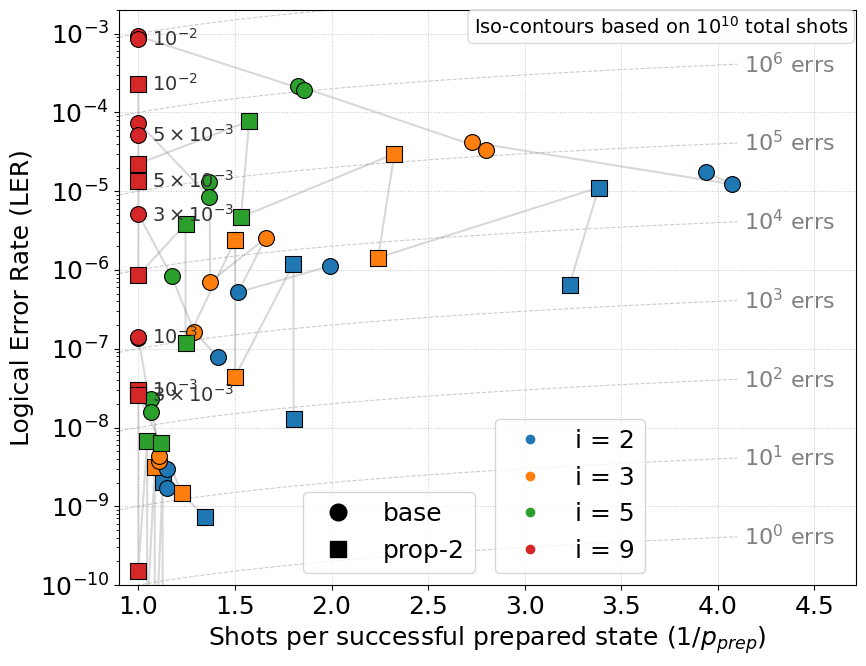

In [30]:
# --- Data Loading and Preparation (unchanged) ---
hw_name = "ibm_torino"
# file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit.csv"
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
# file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
expected_error_targets: List[float] = [1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7]
ler_ylim: List[float] = [1e-10, 2e-3]

# n = [3]
# # shots = [1e7]
# # lstate_values = ["x"]
# # i_values = [2, 3, 5]
# lstate_values = ["z"]
# i_values = [4, 6, 7]

# n = [4]
# # for x
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
# i_values = [2, 9]

# # for z
# lstate_values = ["z"]
# i_values = [8, 12, 14, 15]

# n = [5]
# # for x
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9, 17]

# n = [5]
# # for z
# lstate_values = ["z"]
# i_values = [16, 24, 28, 30, 31]



sim_type_values = ["normal", "m1"]




# create_figure_lerpareto_normal(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/")
# create_figure_pareto_prep_vs_ler(file_path, n, lstate_values, i_values, sim_type_values, expected_error_targets, ler_ylim, out_path="./output/STIM/normal/")
create_figure_pareto_refined(file_path, n, lstate_values, i_values, sim_type_values, expected_error_targets, ler_ylim, 
                             out_path=f"./output/STIM/normal/baseline_polar_pareto_n{n[0]}_{lstate_values[0]}")

## Decay Prep Rate

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
import numpy as np
import os
from matplotlib.ticker import MaxNLocator
from matplotlib.container import BarContainer # Needed for BarContainer filtering

def plot_result_decay_rate_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                      i_val, shots_val, hw_name=None,
                                ler_ylim_min=None, ler_ylim_max=None, number_below = False):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), with percentage comparison between sim_types.
    """
    df = pd.read_csv(file_path)

    # 2a. Filter the data to a single scenario
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        # (df['n'] == n_val) &
        # (df['comp_type'] == "na") &
        (df['lstate'] == lstate_val)
    ].copy()

    # --- Data Preparation ---
    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # Force integer type for 'i' immediately
    if 'n' in filtered_df.columns:
        filtered_df['n'] = filtered_df['n'].astype(int)
        
    # Get error columns
    # prep_rate_error_col = get_error_col('prep_rate', filtered_df.columns)
    prep_rate_error_col = "prep_rate_SD"
    # ler_error_col = get_error_col('LER', filtered_df.columns)
    ler_error_col = "LER_SD"

    if not prep_rate_error_col or not ler_error_col:
         print("Error: Could not find required error columns (_SEM or _SD).")
         return
    
    # 2c-2f. Prepare DataFrames for plotting
    pivot_df_prep_rate = filtered_df.pivot(index='n', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    # pivot_df_prep_rate_err = filtered_df.pivot(index='n', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    # pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values='LER').sort_index(axis=1, ascending=False)
    # pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)

    # --- 3. Plotting ---

    fig, ax1 = plt.subplots(figsize=(6, 4)) 
    # Adjusted Y-limit for annotation space
    ax1.set_ylim(0, 1.1) 

    # Prep Rate Bar Plot (Primary Axis)
    # prep_rate_error_values = pivot_df_prep_rate_err.values.T

    # Plotting the bars
    pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        # yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # Get the BarContainers and Column names for comparison
    bar_containers = [c for c in ax1.containers if isinstance(c, BarContainer)]
    
    # --- 4. Customizing Aesthetics and Legend ---

    ax1.set_xlabel('Check layers ($n$)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    # Fix: Integer X-Labels
    ax1.set_xticklabels(pivot_df_prep_rate.index.astype(int), rotation=0)

    # Combine Legends
    bar_handles = [c[0] for c in bar_containers] 
    
    # Labels adjusted for comparison names
    bar_labels = [
        # "$p_{prep}$ - " + f"{l}"
        "$p_{prep}$ - prop-2" if l == 'm1' else "$p_{prep}$ - base"
        for l in pivot_df_prep_rate.columns
    ]

    ax1.legend(
        bar_handles,
        bar_labels,
        loc='upper right',
        fontsize=15
    )

    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    # ax2.grid(False)

    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_decay.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

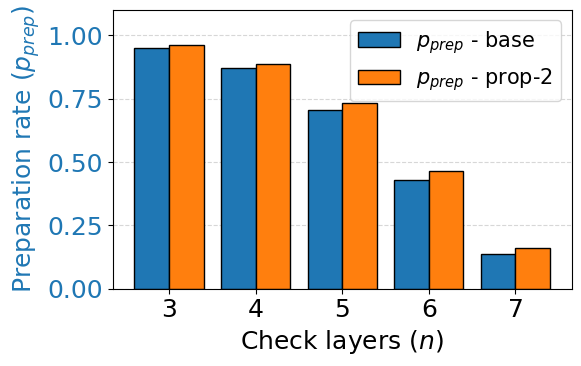

In [32]:
n_val = 4

file_path = f"./output/STIM/normal/polar_results_json_normal_scaling_combined.csv"


# p_error_val = 0.005
p_error_val = 0.001
shots_val = 100

# p_error_val = 1

sim_type_val = ["normal", "m1"]
i_val = [2]
lstate_val = "x"


plot_result_decay_rate_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=5e-6, ler_ylim_max=1e-3) 


# Qiskit - Torino

## Find Best Position

In [82]:
n_val = 4
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
p_error_val = 1
shots_val = 100
sim_type_val = ["normal"]
# i_val = [2, 3, 5, 9]
i_val = range(2, (2**n_val))
lstate_val = "z"

plot_result_rate_profiling_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, hw_name, ler_ylim_min=5e-6, ler_ylim_max=1e-0, number_below = True) # 0.005


KeyError: 'decoder_type'

## Top 4 Position

In [83]:
n_val = 4
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
p_error_val = 1
shots_val = 100
sim_type_val = ["normal", "m1"]
# i_val = [2, 3, 5, 9]
# lstate_val = "x"
lstate_values = ["z"]
i_val = [8, 12, 14, 15]

plot_result_rate_profiling_normal_specific(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, hw_name, ler_ylim_min=5e-6, ler_ylim_max=1e-1, number_below=True) # 0.005


KeyError: 'decoder_type'

In [140]:
# 1. Define the helper function globally or at the beginning of the script
def get_error_col(rate_col, df_cols):
    """Checks for the presence of the SEM or SD column name for a given rate."""
    sem_col = f'{rate_col}_SEM'
    sd_col = f'{rate_col}_SD'
    if sem_col in df_cols:
        return sem_col
    elif sd_col in df_cols:
        return sd_col
    return None

def create_figure_peprep_accepted_qiskit(file_path, n_values, lstate_values, shots, i_values, sim_type_values, decoder_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering ---
    df = pd.read_csv(file_path)
    
    # 2. Determine the correct LER error column name
    # ler_error_col = get_error_col('prep_rate', df.columns)
    ler_error_col = "prep_rate_SEM"
    if not ler_error_col:
        print("Error: Could not find required LER error column (_SEM or _SD).")
        return
    
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['i'].isin(i_values)) &
        (df['decoder_type'].isin(decoder_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    # Ensure the error column is available in the filtered data
    if ler_error_col not in filtered_df.columns:
        print(f"Error: Filtered data does not contain the determined error column: {ler_error_col}")
        return

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() 
    
    # Set scales explicitly before plotting.
    # Note: semilogy plots Y log and X linear.
    # ax.set_xscale('log') 
    # ax.set_yscale('log')
    
    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    data_handles = []
    data_labels = []
    sim_type_proxies = {} 
    
    # Placeholder for the filename to be correct if n_values is non-empty
    n_for_file = n_values[0] if n_values else 'N'
    lstate_for_file = lstate_values[0] if lstate_values else 'L'


    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, '-') 
        
        try:
            color_idx = i_values.index(i)
            color_style = CB_color_cycle_polar[color_idx % len(CB_color_cycle_polar)]
        except ValueError:
            color_style = 'black'

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # data_label = f'n={n}, L. {str_log} [i={int(i)}]'
        data_label = f'i = {int(i)}'
        
        # 3. Use ax.errorbar for plotting with error bars
        # The 'fmt' argument combines marker and line style
        line, _, _ = ax.errorbar(
            group_df['p_error'],
            group_df['prep_rate'],
            yerr=group_df[ler_error_col], # <-- ERROR BARS integrated here
            fmt=f'{marker}{linestyle}',    # Combines marker and line (e.g., 'o-')
            fillstyle=marker_fill,
            color=color_style,
            capsize=3,                     # Size of the caps on the error bars
            label='_nolegend_',
            zorder=3
        )
        
        # Ensure we only get the line handle, not the error bars, for the legend
        if line.get_label() == '_nolegend_':
            # Remove line from legend if it was added automatically
            line.set_label(data_label) 
        
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        if str_sim_type not in sim_type_proxies:
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (e.g., for comparison, if needed)
    # Note: For log-log or linear-log plots, y=x line is often inappropriate.
    
    x_min_limit = 0
    x_max_limit = 1.02
    y_min_limit = 0
    y_max_limit = 1.02

    # 4. Create and Place Legends
    
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        loc='lower left',
        bbox_to_anchor=(0, 0.30),
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    ax.add_artist(legend1)

    legend2 = ax.legend(
        data_handles,
        data_labels,
        loc='lower left',
        bbox_to_anchor=(0, 0.0), 
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # --- Remaining Plot Styling ---

    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    ax.set_xlabel(f'Physical Error Rate Scaling Factor ({hw_name})')
    ax.set_ylabel('Preparation Rate ($p_{prep}$)') # Corrected Y-axis label

    ax.grid(True, which="both", ls="--", linewidth=0.5)

    plt.tight_layout()

    # Save the figure
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peprep_n{n_for_file}_{lstate_for_file}.png')
    plt.show()

## Scale Preparation Rate

In [141]:
# --- Data Loading and Preparation (unchanged) ---
n = [4]
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["z"]
i_values = [8, 12, 14, 15]
sim_type_values = ["normal", "m1"]

create_figure_peprep_accepted_qiskit(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/qiskit_clean/", hw_name=hw_name)



TypeError: create_figure_peprep_accepted_qiskit() missing 1 required positional argument: 'decoder_values'

In [86]:
def create_figure_peler_accepted_qiskit(file_path, n_values, lstate_values, shots, i_values, sim_type_values, decoder_values, y_label, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering ---
    df = pd.read_csv(file_path)
    
    # 2. Determine the correct LER error column name
    ler_error_col = get_error_col(y_label, df.columns)
    if not ler_error_col:
        print("Error: Could not find required LER error column (_SEM or _SD).")
        return
    
    if not isinstance(n_values, list):
        n_values = [n_values]

    combine_states = 'combined' in lstate_values
    filter_lstates = ['x', 'z'] if combine_states else lstate_values

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(filter_lstates)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values)) &
        # (df['p_error'] != 0.01) &
        # (df['p_error'] != 0.05) &
        (df['decoder_type'].isin(decoder_values)) &
        (df['LER'] != 0)
    ].copy()

    # Ensure the error column is available in the filtered data
    if ler_error_col not in filtered_df.columns:
        print(f"Error: Filtered data does not contain the determined error column: {ler_error_col}")
        return

    # --- NEW: Intercept and Combine 'x' and 'z' States ---
    if combine_states:
        group_cols = ['n', 'sim_type', 'i', 'p_error', 'decoder_type']
        val_cols = [y_label, ler_error_col]
        
        # Pivot X and Z columns side by side per parameter set
        pivot_combined = filtered_df.pivot_table(
            index=group_cols,
            columns='lstate',
            values=val_cols
        ).reset_index()
        
        # Flatten MultiIndex columns safely: ('LER', 'x') -> 'LER_x'
        pivot_combined.columns = [
            f"{col[0]}_{col[1]}" if col[1] else col[0] 
            for col in pivot_combined.columns
        ]
        
        # Calculate combined LER metric
        pivot_combined[y_label] = 1 - ((1 - pivot_combined[f"{y_label}_x"]) * (1 - pivot_combined[f"{y_label}_z"]))
        
        # Propagate error bars for LER SD / SEM
        if f"{ler_error_col}_x" in pivot_combined.columns and f"{ler_error_col}_z" in pivot_combined.columns:
            pivot_combined[ler_error_col] = (1 - pivot_combined[y_label]) * np.sqrt(
                (pivot_combined[f"{ler_error_col}_x"] / (1 - pivot_combined[f"{y_label}_x"])).fillna(0)**2 +
                (pivot_combined[f"{ler_error_col}_z"] / (1 - pivot_combined[f"{y_label}_z"])).fillna(0)**2
            )
            
        # Set the label back to 'combined' so the downstream grouping logic functions perfectly
        pivot_combined['lstate'] = 'combined'
        filtered_df = pivot_combined

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() 
    
    # Set scales explicitly before plotting.
    # Note: semilogy plots Y log and X linear.
    # ax.set_xscale('log') 
    ax.set_yscale('log')
    
    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'i'])
    
    data_handles = []
    data_labels = []
    sim_type_proxies = {} 
    
    # Placeholder for the filename to be correct if n_values is non-empty
    n_for_file = n_values[0] if n_values else 'N'
    lstate_for_file = lstate_values[0] if lstate_values else 'L'


    # 2. Iterate through each group and plot it
    for (n, sim_type, i), group_df in grouped:
        lstate = "x"
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, '-') 
        
        try:
            color_idx = i_values.index(i)
            color_style = CB_color_cycle_polar[color_idx % len(CB_color_cycle_polar)]
        except ValueError:
            color_style = 'black'

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-2"
        else:
            str_sim_type = "base"

        # data_label = f'n={n}, L. {str_log} [i={int(i)}]'
        data_label = f'i = {int(i)}'
        
        # 3. Use ax.errorbar for plotting with error bars
        # The 'fmt' argument combines marker and line style
        line, _, _ = ax.errorbar(
            group_df['p_error'],
            group_df[y_label],
            # yerr=group_df[ler_error_col], # <-- ERROR BARS integrated here
            fmt=f'{marker}{linestyle}',    # Combines marker and line (e.g., 'o-')
            fillstyle=marker_fill,
            color=color_style,
            capsize=3,                     # Size of the caps on the error bars
            label='_nolegend_',
            zorder=3
        )
        
        # Ensure we only get the line handle, not the error bars, for the legend
        if line.get_label() == '_nolegend_':
            # Remove line from legend if it was added automatically
            line.set_label(data_label) 
        
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        if str_sim_type not in sim_type_proxies:
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (e.g., for comparison, if needed)
    # Note: For log-log or linear-log plots, y=x line is often inappropriate.
    
    x_min_limit = 0
    x_max_limit = 1
    y_min_limit = 5e-7
    y_max_limit = 1e-1

    # 4. Create and Place Legends
    
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    ax.add_artist(legend1)

    legend2 = ax.legend(
        data_handles,
        data_labels,
        loc='lower right',
        bbox_to_anchor=(1, 0.0), 
        frameon=True,
        edgecolor='black',
        fontsize=12
    )
    
    # --- Remaining Plot Styling ---

    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    ax.set_xlabel(f'Physical Error Rate Scaling Factor ({hw_name})')
    ax.set_ylabel('Logical Error Rate (LER)') # Corrected Y-axis label

    ax.grid(True, which="both", ls="--", linewidth=0.5)

    plt.tight_layout()

    # Save the figure
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peler_n{n_for_file}_{lstate_for_file}.png')
    plt.show()

## Scale LER

In [87]:
# --- Data Loading and Preparation (unchanged) ---
n = [4]
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["z"]
i_values = [8, 12, 14, 15]
sim_type_values = ["normal", "m1"]

create_figure_peler_accepted_qiskit(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/qiskit/", hw_name=hw_name)



TypeError: create_figure_peler_accepted_qiskit() missing 2 required positional arguments: 'decoder_values' and 'y_label'

## Scale Cost

In [88]:
import matplotlib.lines as mlines
def create_figure_pecost_accepted_qiskit(file_path, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    df = pd.read_csv(file_path)
    df["cost_save"] = 1 - df["cost"]

    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['i'].isin(i_values)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(7, 5))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        # linestyle = linestyle_map.get(sim_type, 'm1') 
        linestyle = linestyle_map.get(n, 'm1') 
        color_idx = i_values.index(i)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        # if sim_type == "m1":
        #     str_sim_type = "prop-2"
        # elif sim_type == "m2":
        #     str_sim_type = "prop-3"
        # else:
        #     str_sim_type = "base"

        str_sim_type = f"N = {pow(2,n)}"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'i = {i}'
        
        # Plot the data
        line, = ax.plot(
            group_df['p_error'],
            group_df['cost_save'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 0
    x_max_limit = 1
    y_min_limit = -0.01
    y_max_limit = 0.6

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='upper left',
        bbox_to_anchor=(0.01, 1),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='upper left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.80), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate Scaling Factor (ibm_torino)')
    ax.set_ylabel('Resource Saving ($\eta_{\mathrm{save}}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_pecost_n{n_values}_{lstate_values[0]}.png')
    plt.show()

<>:139: SyntaxWarning: invalid escape sequence '\e'
<>:139: SyntaxWarning: invalid escape sequence '\e'
/var/folders/v6/623nkjns6rs5jqzt737r741m0000gn/T/ipykernel_73670/1141039915.py:139: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('Resource Saving ($\eta_{\mathrm{save}}$)')


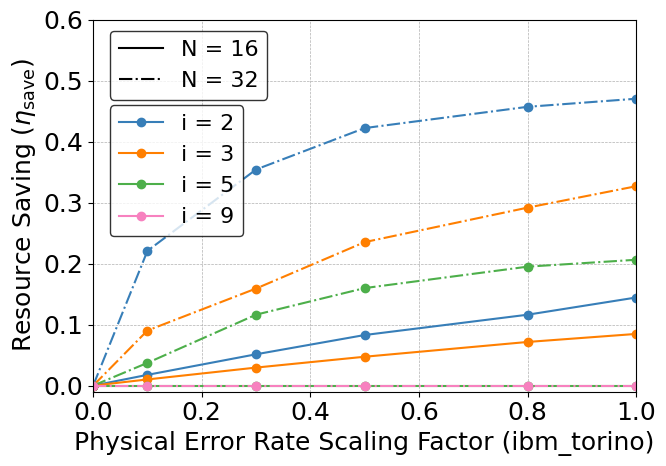

In [89]:

n = [4, 5]
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
shots = 1000
lstate_values = ["x"]
i_values = [2, 3, 5, 9]
sim_type_values = ["m2"]


create_figure_pecost_accepted_qiskit(file_path, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/normal/", hw_name=hw_name)



## Pareto Plot

In [90]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from typing import List, Dict, Any


def create_figure_pareto_refined_torino(
    file_path,
    n_values,
    lstate_values,
    i_values,
    sim_type_values,
    expected_error_targets=[1e2, 1e3, 1e4, 1e5, 1e6],
    ler_ylim=[1e-10, 1e-2],
    out_path="pareto_plot_refined.png",
    countour_shots=1e10
):
    # --- 1. Data Loading ---
    df = pd.read_csv(file_path)

    # Filter Data
    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['p_error'] != 0.05) & 
        (df['p_error'] != 0.01) &
        (df['i'].isin(i_values)) &
        (df['LER'] != 0) &
        (df['sim_type'].isin(sim_type_values))
    ].copy()

    # Sort for consistent line plotting (connect small i to large i)
    filtered_df = filtered_df.sort_values(by=['p_error', 'sim_type', 'i'])
    filtered_df["attempts_per_success"] = 1.0 / filtered_df["prep_rate"]

    # --- 2. Setup Plot ---
    fig, ax = plt.subplots(figsize=(9, 7))

    # --- 3. Plot Iso-Contours (Background) ---
    # x_min, x_max = filtered_df["attempts_per_success"].min() * 0.85, filtered_df["attempts_per_success"].max() * 1.0
    x_min, x_max = 0.9, 3.7
    x_vals = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    shots = countour_shots

    for t in expected_error_targets:
        ler_vals = (t / shots) * x_vals
        # Check if line is within visible Y-range to avoid clutter
        if np.any((ler_vals > ler_ylim[0]) & (ler_vals < ler_ylim[1])):
            ax.plot(x_vals, ler_vals, linestyle="--", linewidth=0.8, color="gray", alpha=0.4, zorder=1)
            
            # Inline Labeling for Contours (Cleaner than Legend)
            # Find a nice spot (e.g., near the right edge)
            y_pos_at_max = (t / shots) * x_max
            if ler_ylim[0] < y_pos_at_max < ler_ylim[1]:
                ax.text(
                    x_max, y_pos_at_max, 
                    f" {format_to_mathtext(t)} errs", 
                    fontsize=16, color="gray", va="center"
                )

    # --- 4. Plot Data & Grouping Lines ---
    
    # Create a sequential color map for 'i'
    # Normalize i values to map to colors
    norm = mcolors.Normalize(vmin=min(i_values), vmax=max(i_values))
    cmap = cm.viridis  # Sequential colormap is better for ordered data like 'i'

    # Group by p_error and sim_type to draw connecting lines
    groups = filtered_df.groupby(['p_error', 'sim_type'])

    for (p_err, s_type), group in groups:
        # Sort group by 'i' to ensure the line follows the iteration order
        group = group.sort_values('i')
        
        # Draw the connecting line (The "Group" visualizer)
        ax.plot(
            group["attempts_per_success"], 
            group["LER"], 
            color="gray", 
            linestyle="-", 
            linewidth=1.5, 
            alpha=0.3, 
            zorder=2
        )

        # Add a single label for this p_error group
        # We place it near the last point (largest i) or first point
        if s_type == "normal":
            xytext_pos = (10, 0)
        else:
            xytext_pos = (10, 0)

        if lstate_values[0] == "x":
            if p_err == 0.1 and s_type == "m1":
                xytext_pos = (-10, -17)
            elif p_err == 0.3 and s_type == "m1":
                xytext_pos = (-10, -17)
            elif p_err == 0.5 and s_type == "m1":
                xytext_pos = (-10, -17)
        else:
            if s_type == "m1":
                xytext_pos = (-10, -17)


        if lstate_values[0] == "z":
            idx = -1
        else:
            idx = 0

        last_point = group.iloc[idx]
        ax.annotate(
            p_err, 
            xy=(last_point["attempts_per_success"], last_point["LER"]), # The point to label
            xytext=xytext_pos,             # Shift 10 points right, 0 points up
            textcoords="offset points", # Interpret xytext as screen pixels, not data coordinates
            fontsize=14, 
            # fontweight='bold', 
            color="#333333",
            va="center",
            zorder=10
        )

        # Plot the actual scatter points on top
        for _, row in group.iterrows():
            ipos = row["i"]
            color = COLOR_MAP_PARETO.get(ipos, 'k')
            ax.scatter(
                row["attempts_per_success"],
                row["LER"],
                s=130,
                marker=MARKER_MAP.get(s_type, 'o'),
                # color=cmap(norm(row['i'])), # Color mapped to 'i'
                color=color, # Color mapped to 'i'
                edgecolor="k",
                linewidth=0.8,
                zorder=5
            )

    # --- 5. Legends ---
    
    # Legend 1: Simulation Type (Markers)
    marker_handles = [
        mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label="prop-2") if l == "m1" 
        else mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label=l)
        for l, m in MARKER_MAP.items()
    ]
    leg1 = ax.legend(handles=marker_handles, loc="lower right", bbox_to_anchor=(0.5, 0), frameon=True)
    ax.add_artist(leg1)

    # Legend 2: Iterations (Colorbar approach or discrete legend)
    # Since specific discrete 'i' values are important, we use a discrete legend
    i_handles = []
    sorted_i = sorted(i_values)
    for val in sorted_i:
        i_handles.append(mlines.Line2D([], [], color=COLOR_MAP_PARETO.get(val, 'k'), marker='o', linestyle='None', label=f"i = {val}"))
    
    ax.legend(handles=i_handles, loc="lower right", bbox_to_anchor=(0.73, 0), frameon=True)

    # --- 6. Final Styling ---
    ax.set_xscale("linear") # Or log, depending on preference
    ax.set_yscale("log")
    ax.set_ylim(ler_ylim)
    ax.set_xlim(left=x_min, right=x_max * 1.15) # Add extra space on right for labels

    ax.set_xlabel(r"Shots per successful prepared state ($1 / p_{prep}$)")
    ax.set_ylabel("Logical Error Rate (LER)")
    # ax.set_title(f"Pareto Frontier: Overhead vs LER (Shots={format_to_mathtext(shots)})", fontsize=14)
    
    ax.grid(which="major", linestyle=":", linewidth=0.7, alpha=0.7)

    info_text = "Iso-contours based on $10^{10}$ total shots"
    # Add text box to top right
    # x=0.97, y=0.97 puts it in the top right corner relative to axes axes
    # ha='right', va='top' aligns the text box anchor to its own top-right corner
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey')
    ax.text(0.99, 0.99, info_text, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()


NameError: name 'format_to_mathtext' is not defined

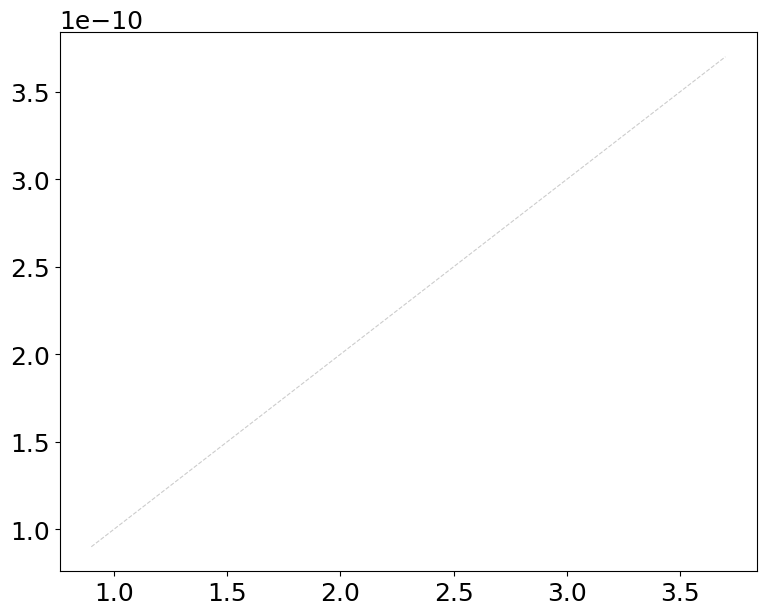

In [91]:
# --- Data Loading and Preparation (unchanged) ---
hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/n5_result/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
expected_error_targets: List[float] = [1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
ler_ylim: List[float] = [1e-10, 1e-1]
n = [4]

# for z
lstate_values = ["z"]
i_values = [8, 12, 14, 15]

# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
# i_values = [2]

sim_type_values = ["normal", "m1"]


create_figure_pareto_refined_torino(file_path, n, lstate_values, i_values, sim_type_values, expected_error_targets, ler_ylim, 
                                       out_path=f"./output/STIM/qiskit/{hw_name}_polar_pareto_n{n[0]}_{lstate_values[0]}.png", countour_shots=1e10)


# Qiskit - Marrakesh

## Find Best Position

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import MaxNLocator
from matplotlib.container import BarContainer

# Temporary placeholder for get_error_col since it wasn't provided in the snippet
def get_error_col(metric, columns):
    # Matches whatever your internal helper function does
    candidates = [c for c in columns if metric.lower() in c.lower() and ('sd' in c.lower() or 'sem' in c.lower())]
    return candidates[0] if candidates else f"{metric}_SD"

plt.rcParams.update({'font.size': 18})

def plot_result_rate_profiling_normal_qiskit(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                      i_val, shots_val, decoder_val, y_label, hw_name=None,
                                      ler_ylim_min=None, ler_ylim_max=None, number_below=False):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), handles single states ('x', 'z') or 'combined' 
    state calculations automatically.
    """
    print(y_label)
    df = pd.read_csv(file_path)

    # Check if we need to combine x and z states
    combine_states = (lstate_val == 'combined')
    target_states = ['x', 'z'] if combine_states else [lstate_val]

    # 2a. Filter the data (Modified to use .isin() for lstate compatibility)
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        (df['n'] == n_val) &
        (df['decoder_type'].isin(decoder_val)) &
        (df['lstate'].isin(target_states))
    ].copy()

    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # Identify base error column names before reshaping
    prep_rate_error_col = "prep_rate_SD"
    ler_error_col = get_error_col(y_label, filtered_df.columns)

    # --- NEW: Combine 'x' and 'z' states if requested ---
    if combine_states:
        group_cols = ['sim_type', 'i', 'p_error', 'n', 'decoder_type']
        
        # Identify columns to pivot safely
        val_cols = ['prep_rate', y_label]
        if prep_rate_error_col in filtered_df.columns: val_cols.append(prep_rate_error_col)
        if ler_error_col in filtered_df.columns: val_cols.append(ler_error_col)

        # Pivot x and z side-by-side
        pivot_combined = filtered_df.pivot_table(
            index=group_cols,
            columns='lstate',
            values=val_cols
        ).reset_index()
        
        # Flatten MultiIndex columns: ('prep_rate', 'x') -> 'prep_rate_x'
        pivot_combined.columns = [
            f"{col[0]}_{col[1]}" if col[1] else col[0] 
            for col in pivot_combined.columns
        ]
        
        # Calculate combined metrics
        pivot_combined['prep_rate'] = pivot_combined['prep_rate_x'] * pivot_combined['prep_rate_z']
        pivot_combined[y_label] = 1 - ((1 - pivot_combined[f'{y_label}_x']) * (1 - pivot_combined[f'{y_label}_z']))
        
        # Error propagation for Prep Rate SD (Product Rule)
        if f'{prep_rate_error_col}_x' in pivot_combined.columns:
            pivot_combined[prep_rate_error_col] = pivot_combined['prep_rate'] * np.sqrt(
                (pivot_combined[f'{prep_rate_error_col}_x'] / pivot_combined['prep_rate_x']).fillna(0)**2 +
                (pivot_combined[f'{prep_rate_error_col}_z'] / pivot_combined['prep_rate_z']).fillna(0)**2
            )
        
        # Error propagation for LER SD
        if f'{ler_error_col}_x' in pivot_combined.columns:
            pivot_combined[ler_error_col] = (1 - pivot_combined[y_label]) * np.sqrt(
                (pivot_combined[f'{ler_error_col}_x'] / (1 - pivot_combined[f'{y_label}_x'])).fillna(0)**2 +
                (pivot_combined[f'{ler_error_col}_z'] / (1 - pivot_combined[f'{y_label}_z'])).fillna(0)**2
            )
            
        # Replace filtered_df with the newly calculated combined values
        filtered_df = pivot_combined

    # Force integer type for 'i' immediately
    if 'i' in filtered_df.columns:
        filtered_df['i'] = filtered_df['i'].astype(int)

    # 2c-2f. Prepare DataFrames for plotting (Now completely compatible)
    pivot_df_prep_rate = filtered_df.pivot(index='i', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    pivot_df_prep_rate_err = filtered_df.pivot(index='i', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values=y_label).sort_index(axis=1, ascending=False)
    pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)

    # --- 3. Plotting ---
    fig, ax1 = plt.subplots(figsize=(10, 5)) 
    ax1.set_ylim(0, 1.1) 

    prep_rate_error_values = pivot_df_prep_rate_err.values.T

    pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # LER Line Plot (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.set_yscale('log')
    if ler_ylim_min is not None or ler_ylim_max is not None:
        ax2.set_ylim(ler_ylim_min, ler_ylim_max)
    
    x_positions = ax1.get_xticks()
    ler_handles = []
    ler_colors = {'normal': '#2ca02c', 'm1': '#9467bd'}
    ler_markers = {'normal': 'o', 'm1': 's'}
    
    # Extract Baselines for Calculations
    baseline_lookup = {}
    baseline_df = filtered_df[filtered_df['i'] == 7]
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            baseline_lookup[row['sim_type']] = {
                'prep': row['prep_rate'],
                'ler': row[y_label]
            }

    # Plot LER Lines and Annotate LER Points
    for idx, sim_type in enumerate(sim_type_val):
        if sim_type in pivot_df_ler.columns:
            ler_mean = pivot_df_ler[sim_type].values
            ler_err = pivot_df_ler_err[sim_type].values
            x_line_coords = x_positions
            
            ler_line, _, _ = ax2.errorbar(
                x_line_coords, 
                ler_mean,
                # yerr=ler_err, 
                fmt=ler_markers.get(sim_type, 'o'), 
                color=ler_colors.get(sim_type, 'black'),
                linestyle='-',
                linewidth=2,
                capsize=3,
                zorder=3,
                label=f'LER ({sim_type.upper()})'
            )
            ler_handles.append(ler_line)

    # Annotate Prep Rate Bars
    bar_cols = pivot_df_prep_rate.columns
    bar_containers = [c for c in ax1.containers if isinstance(c, BarContainer)]

    for idx, container in enumerate(bar_containers):
        if idx < len(bar_cols):
            sim_type = bar_cols[idx]
            if sim_type in baseline_lookup:
                base_prep = baseline_lookup[sim_type]['prep']
                
                bar_idx = 0
                for rect, val in zip(container, pivot_df_prep_rate[sim_type]):
                    if base_prep > 0:
                        pct_diff = ((val - base_prep) / base_prep) * 100
                        text_color = 'green' if pct_diff >= 0 else 'red'
                        sign = '+' if pct_diff >= 0 else '-'
                        
                        height = rect.get_height()
                        text_pos = height + 0.02
                        if number_below:
                            text_pos = height + 0.02 + (0.14 * prep_rate_error_values[0][bar_idx] / max(prep_rate_error_values[0]))
                            if bar_idx == 3:
                                text_pos = text_pos + 0.07

                        bar_idx = bar_idx + 1
                            
                        ax1.text(
                            rect.get_x() + rect.get_width() / 2, 
                            text_pos,  
                            f"{sign}{abs(pct_diff):.0f}%", 
                            color=text_color, 
                            ha='center', 
                            va='bottom', 
                            fontsize=12, 
                        )

    # Draw Baseline Lines
    if not baseline_df.empty:
        print("Adding horizontal baseline lines for i=7 values.")
        for index, row in baseline_df.iterrows():
            sim_type = row['sim_type']
            
            prep_color = '#1f77b4' if sim_type == 'normal' else '#ff7f0e'
            ax1.axhline(
                y=row['prep_rate'],
                color=prep_color, 
                linestyle=':', 
                linewidth=1, 
                zorder=1,
            )
            
            ler_color = ler_colors.get(sim_type, 'black')
            ax2.axhline(
                y=row[y_label],
                color=ler_color, 
                linestyle='--', 
                linewidth=1, 
                zorder=1,
            )

    # Customizing Aesthetics and Legend
    ax1.set_xlabel('Information Position (i)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2.set_ylabel('Logical error rate (LER)', color=ler_colors['normal'])
    ax2.tick_params(axis='y', labelcolor=ler_colors['normal'])

    ax1.set_xticklabels(pivot_df_prep_rate.index.astype(int), rotation=0)

    bar_handles = [c[0] for c in bar_containers] 
    bar_labels = ["$p_{prep}$ - prop-2" if l == 'm1' else "$p_{prep}$" for l in pivot_df_prep_rate.columns]
    ler_labels = [f"LER - prop-2" if l == 'm1' else f"LER" for l in pivot_df_ler.columns]
    
    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + ler_labels

    ax1.legend(combined_handles, combined_labels, loc='upper left', fontsize=17)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False)
    plt.tight_layout()

    # Save the figure
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_all_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

LER_error
Adding horizontal baseline lines for i=7 values.


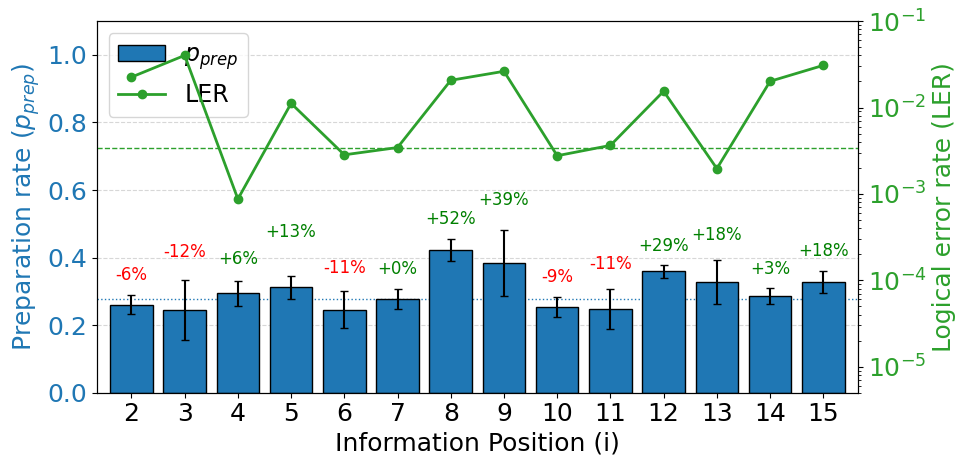

In [93]:
n_val = 4
hw_name = "ibm_marrakesh"
file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n{n_val}_combined.csv"
p_error_val = 1.0
shots_val = 100
sim_type_val = ["normal"]
# i_val = [2, 3, 5, 9]
i_val = range(2, (2**n_val))
lstate_val = "combined"
decoder_type_val = ["val"]
y_label = 'LER_error'
# y_label = 'LER_undecided'

plot_result_rate_profiling_normal_qiskit(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, decoder_type_val, y_label, hw_name, ler_ylim_min=5e-6, ler_ylim_max=1e-1, number_below = True) # 0.005


## Top 4 Position

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import MaxNLocator
from matplotlib.container import BarContainer 

plt.rcParams.update({'font.size': 18})

def plot_result_rate_profiling_normal_specific_qiskit(file_path, n_val, p_error_val, sim_type_val, lstate_val,
                                               i_val, shots_val, decoder_val, hw_name=None,
                                               ler_ylim_min=None, ler_ylim_max=None, number_below=False):
    """
    Plots the Preparation Rate (Prep_Rate) and Logical Error Rate (LER) against 
    the Information Position (i), with percentage comparison between sim_types.
    Handles 'x', 'z', or 'combined' logical states automatically.
    """
    df = pd.read_csv(file_path)

    # --- 1. Handle Combined State Filtering Logic ---
    combine_states = (lstate_val == 'combined')
    target_states = ['x', 'z'] if combine_states else [lstate_val]

    # 2a. Filter the data using .isin() for the lstate target list
    filtered_df = df[
        (df['sim_type'].isin(sim_type_val)) &
        (df['i'].isin(i_val)) &
        (df['p_error'] == p_error_val) &
        (df['n'] == n_val) &
        (df['decoder_type'].isin(decoder_val)) &
        (df['lstate'].isin(target_states))
    ].copy()

    # --- Data Verification ---
    if filtered_df.empty:
        print("Warning: Filtered DataFrame is empty. Check your filter values.")
        return

    # Define strict column names for mapping errors
    prep_rate_error_col = "prep_rate_SD"
    ler_error_col = "LER_SD"

    # --- 2. Combine 'x' and 'z' States Math & Error Propagation ---
    if combine_states:
        group_cols = ['sim_type', 'i', 'p_error', 'n', 'decoder_type']
        val_cols = ['prep_rate', 'LER', prep_rate_error_col, ler_error_col]
        # Keep only the target columns that exist in the physical CSV file
        val_cols = [c for c in val_cols if c in filtered_df.columns]
        
        # Pivot X and Z columns side by side per parameter set
        pivot_combined = filtered_df.pivot_table(
            index=group_cols,
            columns='lstate',
            values=val_cols
        ).reset_index()
        
        # Flatten MultiIndex columns safely: ('LER', 'x') -> 'LER_x'
        pivot_combined.columns = [
            f"{col[0]}_{col[1]}" if col[1] else col[0] 
            for col in pivot_combined.columns
        ]
        
        # Calculate combined mean values
        pivot_combined['prep_rate'] = pivot_combined['prep_rate_x'] * pivot_combined['prep_rate_z']
        pivot_combined['LER'] = 1 - ((1 - pivot_combined['LER_x']) * (1 - pivot_combined['LER_z']))
        
        # Error propagation for Prep Rate SD (Product rule formula)
        if 'prep_rate_SD_x' in pivot_combined.columns and 'prep_rate_SD_z' in pivot_combined.columns:
            pivot_combined[prep_rate_error_col] = pivot_combined['prep_rate'] * np.sqrt(
                (pivot_combined['prep_rate_SD_x'] / pivot_combined['prep_rate_x']).fillna(0)**2 +
                (pivot_combined['prep_rate_SD_z'] / pivot_combined['prep_rate_z']).fillna(0)**2
            )
        
        # Error propagation for LER SD (Independent combination sequence)
        if 'LER_SD_x' in pivot_combined.columns and 'LER_SD_z' in pivot_combined.columns:
            pivot_combined[ler_error_col] = (1 - pivot_combined['LER']) * np.sqrt(
                (pivot_combined['LER_SD_x'] / (1 - pivot_combined['LER_x'])).fillna(0)**2 +
                (pivot_combined['LER_SD_z'] / (1 - pivot_combined['LER_z'])).fillna(0)**2
            )
            
        # Overwrite filtered_df with combined dataset layout
        filtered_df = pivot_combined

    # Force integer type for 'i' immediately
    if 'i' in filtered_df.columns:
        filtered_df['i'] = filtered_df['i'].astype(int)

    # 2c-2f. Prepare DataFrames for plotting
    pivot_df_prep_rate = filtered_df.pivot(index='i', columns='sim_type', values='prep_rate').sort_index(axis=1, ascending=False)
    pivot_df_prep_rate_err = filtered_df.pivot(index='i', columns='sim_type', values=prep_rate_error_col).sort_index(axis=1, ascending=False)
    pivot_df_ler = filtered_df.pivot(index='i', columns='sim_type', values='LER').sort_index(axis=1, ascending=False)
    pivot_df_ler_err = filtered_df.pivot(index='i', columns='sim_type', values=ler_error_col).sort_index(axis=1, ascending=False)

    # --- 3. Plotting ---
    fig, ax1 = plt.subplots(figsize=(10, 5)) 
    ax1.set_ylim(0, 1.1) 

    # Prep Rate Bar Plot (Primary Axis)
    prep_rate_error_values = pivot_df_prep_rate_err.values.T

    pivot_df_prep_rate.plot(
        kind='bar',
        ax=ax1,
        yerr=prep_rate_error_values, 
        capsize=3, 
        color={'normal': '#1f77b4', 'm1': '#ff7f0e'},
        edgecolor='black',
        zorder=2,
        width=0.8,
        rot=0
    )

    # LER Line Plot (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.set_yscale('log')
    ax2.set_ylim(ler_ylim_min, ler_ylim_max) 
    
    x_positions = ax1.get_xticks()
    ler_handles = []
    ler_colors = {'normal': '#2ca02c', 'm1': '#9467bd'}
    ler_markers = {'normal': 'o', 'm1': 's'}
    
    # Plot LER Lines
    for idx, sim_type in enumerate(sim_type_val):
        if sim_type in pivot_df_ler.columns:
            ler_mean = pivot_df_ler[sim_type].values
            
            ler_line, _, _ = ax2.errorbar(
                x_positions,      # Fixed: Pass positionally as X
                ler_mean,         # Fixed: Pass positionally as Y
                # yerr=pivot_df_ler_err[sim_type].values,  # Uncomment if you want error bars active on LER lines
                fmt=ler_markers.get(sim_type, 'o'), 
                color=ler_colors.get(sim_type, 'black'),
                linestyle='-',
                linewidth=2,
                capsize=3,
                zorder=3,
                label=f'LER ({sim_type.upper()})'
            )
            ler_handles.append(ler_line)

    # --- ANNOTATE COMPARISON: prop-2 vs BASE ---
    bar_containers = [c for c in ax1.containers if isinstance(c, BarContainer)]
    
    if len(pivot_df_prep_rate.columns) >= 2:
        col_base = pivot_df_prep_rate.columns[0] 
        col_prop1 = pivot_df_prep_rate.columns[1] 
        
        if len(bar_containers) >= 2:
            container_prop1 = bar_containers[1] 
            
            bar_idx = 0
            for i_idx, i_val_idx in enumerate(pivot_df_prep_rate.index):
                val_base = pivot_df_prep_rate.loc[i_val_idx, col_base]
                val_prop1 = pivot_df_prep_rate.loc[i_val_idx, col_prop1]
                
                if val_base > 0:
                    pct_diff = ((val_prop1 - val_base) / val_base) * 100
                    text_color = 'green' if pct_diff >= 0 else 'red'
                    sign = '+' if pct_diff >= 0 else '-'
                    
                    rect = container_prop1[i_idx]
                    height = rect.get_height()
                    text_pos = height + 0.02

                    if number_below:
                        text_pos = height + 0.02 + (0.14 * prep_rate_error_values[0][bar_idx] / max(prep_rate_error_values[0]))
                        if bar_idx == 2:
                            text_pos = text_pos + 0.04

                    bar_idx = bar_idx + 1
                    
                    ax1.text(
                        rect.get_x() + rect.get_width() / 2, 
                        text_pos, 
                        f"{sign}{abs(pct_diff):.1f}%", 
                        color=text_color, 
                        ha='center', 
                        va='bottom', 
                        fontsize=14, 
                        fontweight='bold',
                        zorder=4
                    )
    
    # --- Draw Baseline Lines (i=7) ---
    baseline_df = filtered_df[filtered_df['i'] == 7]
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            sim_type = row['sim_type']
            
            prep_color = '#1f77b4' if sim_type == 'normal' else '#ff7f0e'
            ax1.axhline(
                y=row['prep_rate'],
                color=prep_color, 
                linestyle=':', 
                linewidth=0.8, 
                zorder=1
            )
            
            ler_color = ler_colors.get(sim_type, 'black')
            ax2.axhline(
                y=row['LER'],
                color=ler_color, 
                linestyle='--', 
                linewidth=0.8, 
                zorder=1
            )

    # --- 4. Customizing Aesthetics and Legend ---
    ax1.set_xlabel('Information Position (i)')
    ax1.set_ylabel('Preparation rate ($p_{prep}$)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2.set_ylabel('Logical error rate (LER)', color=ler_colors['normal'])
    ax2.tick_params(axis='y', labelcolor=ler_colors['normal'])

    ax1.set_xticklabels(pivot_df_prep_rate.index.astype(int), rotation=0)

    # Combine Legends smoothly
    bar_handles = [c[0] for c in bar_containers] 
    bar_labels = ["$p_{prep}$ - prop-2" if l == 'm1' else "$p_{prep}$ - base" for l in pivot_df_prep_rate.columns]
    ler_labels = ["LER - prop-2" if l == 'm1' else "LER - base" for l in pivot_df_ler.columns]
    
    combined_handles = list(bar_handles) + ler_handles
    combined_labels = bar_labels + ler_labels

    ax1.legend(combined_handles, combined_labels, loc='upper right', fontsize=15)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=1)
    ax2.grid(False)
    plt.tight_layout()

    # Save output setup
    output_dir = "./output/STIM/normal"
    os.makedirs(output_dir, exist_ok=True)

    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"
    sim_type_str = '_'.join(sim_type_val)
    # Added lstate_val into the filename layout dynamically to avoid file overwriting
    save_path = f"{output_dir}/{filename_prefix}polar_n{n_val}_{p_error_val}_{sim_type_str}_{shots_val}_{lstate_val}_accepted.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

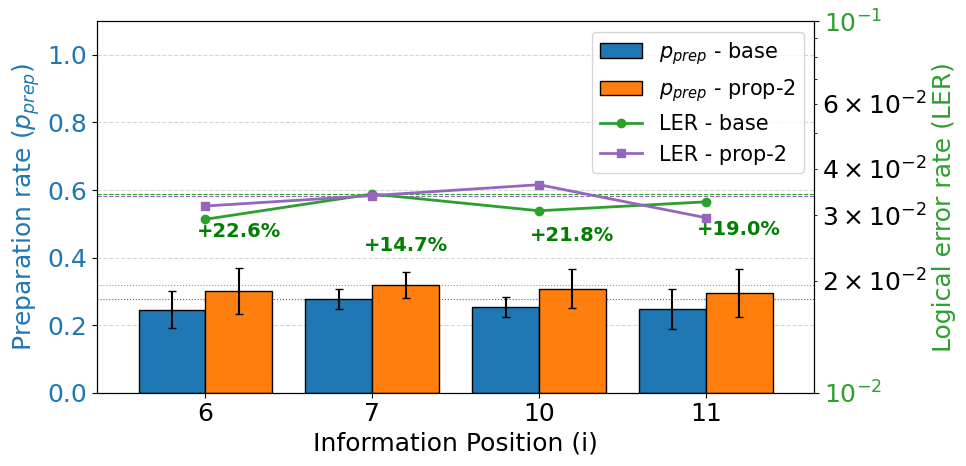

In [95]:
n_val = 4
hw_name = "ibm_marrakesh"
# file_path = f"./output/STIM/qiskit/marrakesh/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n4_combined.csv"
p_error_val = 1
shots_val = 100
sim_type_val = ["normal", "m1"]
# i_val = [2, 3, 5, 9]
# lstate_val = "x"

i_val = [6, 7, 10, 11]
lstate_val = 'combined'
decoder_type_val = ["val"]

plot_result_rate_profiling_normal_specific_qiskit(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, decoder_type_val, hw_name, ler_ylim_min=1e-2, ler_ylim_max=1e-1, number_below=True) # 0.005



## Scale Preparation Rate

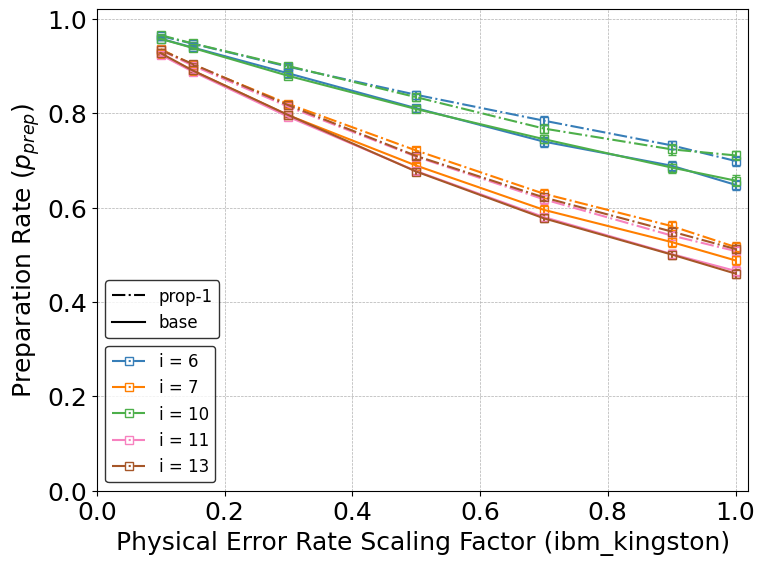

In [144]:
# --- Data Loading and Preparation (unchanged) ---
n = [4]
# hw_name = "ibm_marrakesh"
hw_name = "ibm_kingston"
# file_path = f"./output/STIM/qiskit/marrakesh/{hw_name}_polar_results_json_qiskit_n4_combined.csv"
file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n4_combined.csv"
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["z"]
# i_values = [6,7]
i_values = [6,7,10,11,13]
sim_type_values = ["normal", "m1"]
decoder_values = ["val"] 

create_figure_peprep_accepted_qiskit(file_path, n, lstate_values, shots, i_values, sim_type_values, decoder_values, out_path="./output/STIM/qiskit_clean/", hw_name=hw_name)



### With N

In [154]:
import matplotlib.lines as mlines
def create_figure_peprep_accepted_normal_qiskit_paper(df, n_values, lstate_values, shots, i_values, sim_type_values, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    # df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['i'].isin(i_values)) &
        (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['sim_type'].isin(sim_type_values))
        # (df['LER'] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'lstate', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles

    # 2. Iterate through each group and plot it
    for (n, sim_type, lstate, i), group_df in grouped:
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = n_values.index(n)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'N = {2**n}, i = {round(i)}'
        
        # Plot the data
        line, = ax.semilogx(
            group_df['p_error'],
            group_df['prep_rate'],
            marker=marker,         
            linestyle=linestyle,   
            fillstyle=marker_fill,
            color=color_style,
            label='_nolegend_' # Do not auto-include in legend
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 0.05
    x_max_limit = 1.01
    y_min_limit = 0
    y_max_limit = 1.05

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower left',
        bbox_to_anchor=(0.01, 0.30),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower left',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(0.01, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Preparation Rate ($p_{prep}$)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_peprep_{lstate_values[0]}_paper.png')
    plt.show()

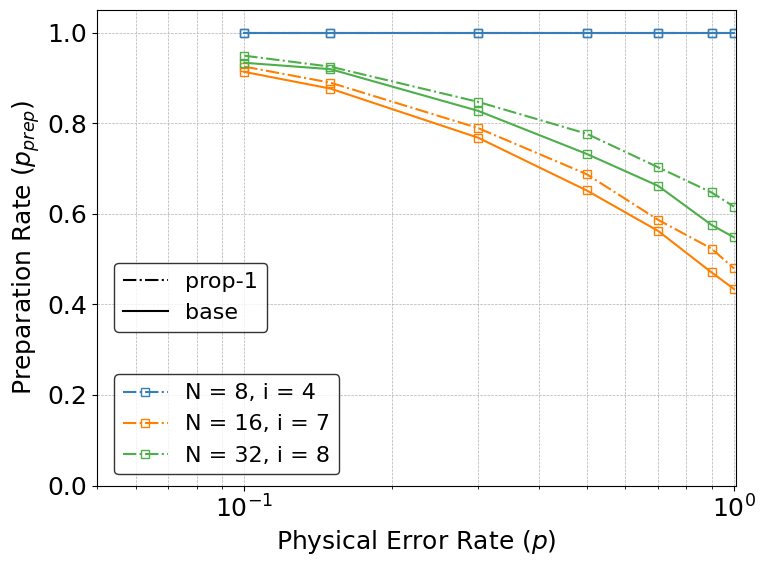

In [157]:
n = [3,4,5,6]
shots = 1000
lstate_values = ["z"]
# i_values = [2, 3, 5, 9]
# lstate_values = ["z"]
i_values = [4, 7, 8, 23]
sim_type_values = ["normal", "m1"]
hw_name  = "ibm_marrakesh"
# hw_name  = "ibm_kingston"

# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n3_combined.csv"
df_3 = pd.read_csv(file_path)

file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n4_combined.csv"
df_4 = pd.read_csv(file_path)

file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n5_combined.csv"
df_5 = pd.read_csv(file_path)

# file_path = f"./output/STIM/clean/polar_results_json_normal_n6_combined.csv"
# df_6 = pd.read_csv(file_path)

df_combined = pd.concat([df_3, df_4, df_5], axis=0, ignore_index=True, sort=False)

conditions = (
    ((df_combined['n'] == 3) & (df_combined['i'] == 4)) |
    ((df_combined['n'] == 4) & (df_combined['i'] == 7)) |
    ((df_combined['n'] == 5) & (df_combined['i'] == 8)) |
    ((df_combined['n'] == 6) & (df_combined['i'] == 23))
)

# Apply the combined filter
filtered_df = df_combined[
    conditions &
    (df_combined['lstate'].isin(lstate_values)) &
    (df_combined['sim_type'].isin(sim_type_values))
].copy()

# # Check the result
# filtered_df[filtered_df["n"] == 4]



create_figure_peprep_accepted_normal_qiskit_paper(filtered_df, n, lstate_values, shots, i_values, sim_type_values, out_path="./output/STIM/qiskit_clean/", hw_name=hw_name)

## Scale LER

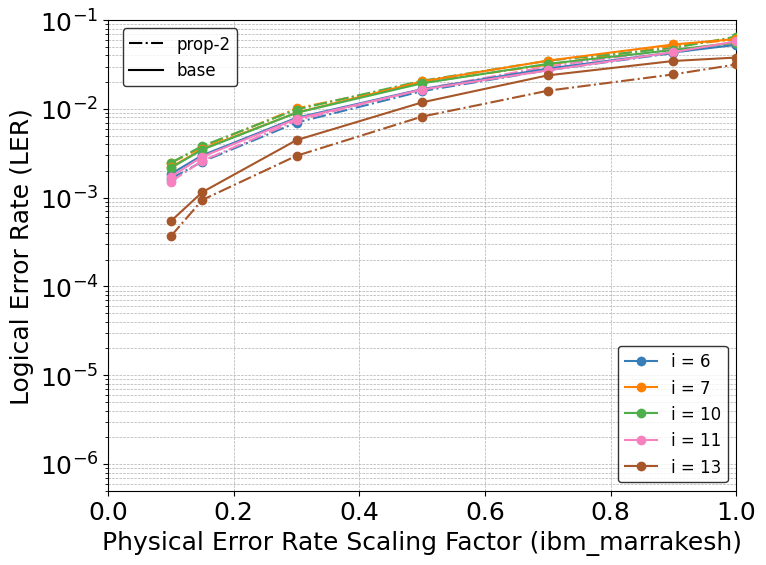

In [145]:
# --- Data Loading and Preparation (unchanged) ---
n = [4]
hw_name = "ibm_marrakesh"
# hw_name = "ibm_kingston"
file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n4_combined.csv"
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = "combined"
# i_values = [6, 7, 10, 11]
# i_values = [6, 7, 10, 11]
# i_values = [4,7,13]
i_values = [6,7,10,11,13]
sim_type_values = ["normal", "m1"]
decoder_values = ["val"]
# y_label = "LER_error"
y_label = "LER_undecided"

create_figure_peler_accepted_qiskit(file_path, n, lstate_values, shots, i_values, sim_type_values, decoder_values, y_label, out_path="./output/STIM/qiskit_clean/", hw_name=hw_name)



### with N

In [158]:
import matplotlib.lines as mlines
def create_figure_peler_accepted_normal_qiskit_paper(df, n_values, lstate_values, shots, i_values, sim_type_values, y_label, decoder_type, out_path="peprep_plot.png", hw_name=None):

    # --- Data Loading and Filtering (As in your original code) ---
    # df = pd.read_csv(file_path)
    
    # Ensure n_values is used correctly if it contains multiple values (as implied by .isin)
    if not isinstance(n_values, list):
        n_values = [n_values]

    filtered_df = df[
        (df['i'].isin(i_values)) &
        # (df['lstate'].isin(lstate_values)) &
        # (df['shots'].isin(shots)) &
        (df['sim_type'].isin(sim_type_values)) &
        (df['p_error'] != 0.0005) &
        (df['p_error'] != 0.0001) &
        (df['p_error'] != 0.00025) &
        (df['p_error'] != 0.00075) &
        (df[y_label] != 0)
    ].copy()

    sorted_df = filtered_df.sort_values(by=['n', 'i', 'p_error'])

    # --- Revised Plotting Code ---

    plt.figure(figsize=(8, 6))
    ax = plt.gca() # Get the current axes

    # 1. Group the filtered data
    grouped = sorted_df.groupby(['n', 'sim_type', 'i'])
    
    # Containers for the two separate legends
    data_handles = []
    data_labels = []
    sim_type_proxies = {} # Stores unique proxy artists for line styles
    ax.set_yscale('log')

    # 2. Iterate through each group and plot it
    for (n, sim_type, i), group_df in grouped:
        lstate = 'x' 
        marker = marker_map.get(lstate, 'x')  
        marker_fill = marker_fill_map.get(lstate, 'x')  
        linestyle = linestyle_map.get(sim_type, 'm1') 
        color_idx = n_values.index(n)
        color_style = CB_color_cycle_polar[color_idx]

        if lstate == "x":
            str_log = "|+>"
        else:
            str_log = "|0>"

        if sim_type == "m1":
            str_sim_type = "prop-1"
        else:
            str_sim_type = "base"

        # **Important:** Use a temporary label ('_nolegend_') to prevent
        # these lines from automatically appearing in the default legend.
        # data_label = f'n={n}, L. {str_log} [i={i}]'
        data_label = f'N = {2**n}, i = {round(i)}'
        
        # # Plot the data
        # line, _, _ = ax.errorbar(
        #     group_df['p_error'],
        #     group_df[y_label],
        #     marker=marker,         
        #     linestyle=linestyle,   
        #     fillstyle=marker_fill,
        #     color=color_style,
        #     label='_nolegend_' # Do not auto-include in legend
        #     zorder=3
        # )

        line, _, _ = ax.errorbar(
            group_df['p_error'],
            group_df[y_label],
            # yerr=group_df[ler_error_col], # <-- ERROR BARS integrated here
            fmt=f'{marker}{linestyle}',    # Combines marker and line (e.g., 'o-')
            fillstyle=marker_fill,
            color=color_style,
            capsize=3,                     # Size of the caps on the error bars
            label='_nolegend_',
            zorder=3
        )
        
        # Collect handles/labels for the data series legend (Legend 2)
        # We only need one handle per unique data label (n, lstate, i combination)
        if data_label not in data_labels:
            data_handles.append(line)
            data_labels.append(data_label)

        # Collect proxy artists for the simulation type legend (Legend 1)
        if str_sim_type not in sim_type_proxies:
            # Create a simple black line with the unique linestyle
            proxy = mlines.Line2D([], [], color='black', linestyle=linestyle, label=str_sim_type)
            sim_type_proxies[str_sim_type] = proxy

    # 3. Add the x = y guidance line (as in original code)
    # Using hardcoded limits for the example
    x_min_limit = 0.01
    x_max_limit = 1.01
    y_min_limit = 1e-8
    y_max_limit = 1

    # 4. Create and Place Legends
    
    # Legend 1: Simulation Type (Line Style)
    sim_handles = list(sim_type_proxies.values())
    sim_labels = list(sim_type_proxies.keys())
    
    # Place Legend 1 outside the plot area
    legend1 = ax.legend(
        sim_handles,
        sim_labels,
        # title="Method",
        loc='lower right',
        bbox_to_anchor=(1, 0.30),
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # Manually add Legend 1 back to the figure (so the next legend doesn't overwrite it)
    ax.add_artist(legend1)

    # Legend 2: Data Series (Color/Marker)
    # This uses the collected data_handles/data_labels.
    legend2 = ax.legend(
        data_handles,
        data_labels,
        # title="Data Series",
        loc='lower right',
        # Adjust bbox_to_anchor to place it right below Legend 1
        # The y value is estimated based on the height of Legend 1
        bbox_to_anchor=(1, 0.0), # Adjust this anchor point as needed
        frameon=True,
        edgecolor='black',
        fontsize=16
    )
    
    # --- Remaining Plot Styling (As in original code) ---


    # Set Axis Limits 
    ax.set_xlim(x_min_limit, x_max_limit)
    ax.set_ylim(y_min_limit, y_max_limit)

    # Set labels and title
    ax.set_xlabel('Physical Error Rate ($p$)')
    ax.set_ylabel('Logical Error Rate (LER)')

    # Add grid
    ax.grid(True, which="both", ls="--", linewidth=0.5)

    # Adjust layout to make room for the legends (if needed, but bbox_to_anchor handles this)
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.tight_layout()

    # Save the figure
    # plt.savefig(out_path)
    filename_prefix = f"{hw_name}_" if hw_name else "baseline_"

    plt.savefig(f'{out_path}{filename_prefix}polar_pe{y_label}_{decoder_type}_all_paper.png')
    plt.show()

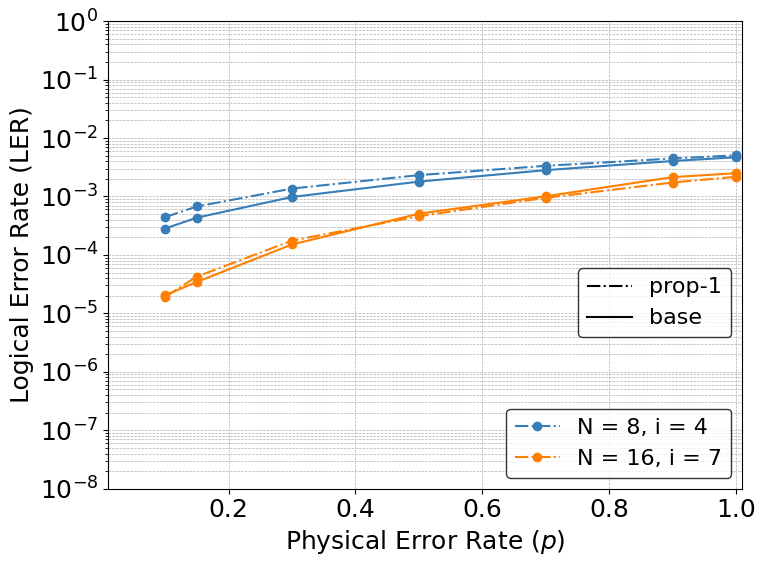

In [ ]:
n = [3,4,5,6]
shots = 1000
# lstate_values = ["x"]
# i_values = [2, 3, 5, 9]
lstate_values = ["x"]
i_values = [4, 7, 8, 23]
sim_type_values = ["normal", "m1"]
dec_type_values = ["val"]

group_cols = ['n', 'i', 'p_error', 'sim_type', 'decoder_type']
y_label = 'LER_error'
# y_label = 'LER_undecided'
hw_name  = "ibm_marrakesh"
# hw_name  = "ibm_kingston"

# --- Data Loading and Preparation (unchanged) ---
file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n3_combined.csv"
df_3 = pd.read_csv(file_path)
pdf_3 = df_3.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_3[y_label] = 1 - ((1 - pdf_3['x']) * (1 - pdf_3['z']))

file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n4_combined.csv"
df_4 = pd.read_csv(file_path)
pdf_4 = df_4.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_4[y_label] = 1 - ((1 - pdf_4['x']) * (1 - pdf_4['z']))

file_path = f"./output/STIM/qiskit_clean/{hw_name}_na_polar_results_json_qiskit_n5_combined.csv"
df_5 = pd.read_csv(file_path)
pdf_5 = df_5.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
pdf_5[y_label] = 1 - ((1 - pdf_5['x']) * (1 - pdf_5['z']))

# file_path = f"./output/STIM/clean/polar_results_json_normal_n6_combined.csv"
# df_6 = pd.read_csv(file_path)
# pdf_6 = df_6.pivot_table(index=group_cols, columns='lstate', values=y_label).reset_index()
# pdf_6[y_label] = 1 - ((1 - pdf_6['x']) * (1 - pdf_6['z']))

# df_combined = pd.concat([pdf_3, pdf_4, pdf_5, pdf_6], axis=0, ignore_index=True, sort=False)
df_combined = pd.concat([pdf_3, pdf_4], axis=0, ignore_index=True, sort=False)

conditions = (
    ((df_combined['n'] == 3) & (df_combined['i'] == 4)) |
    ((df_combined['n'] == 4) & (df_combined['i'] == 7)) |
    ((df_combined['n'] == 5) & (df_combined['i'] == 8)) |
    ((df_combined['n'] == 6) & (df_combined['i'] == 23))
)

# conditions = (
#     ((df_combined['n'] == 4) & (df_combined['i'] == 4)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 6)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 7)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 10)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 11)) |
#     ((df_combined['n'] == 4) & (df_combined['i'] == 13))
# )

# Apply the combined filter
filtered_df = df_combined[
    conditions &
    # (df_combined['lstate'].isin(lstate_values)) &
    (df_combined['sim_type'].isin(sim_type_values)) &
    (df_combined['decoder_type'].isin(dec_type_values)) 
].copy()

# # Check the result
# filtered_df[filtered_df["n"] == 4]



create_figure_peler_accepted_normal_qiskit_paper(filtered_df, n, lstate_values, shots, i_values, sim_type_values, y_label,dec_type_values[0], out_path="./output/STIM/qiskit_clean/", hw_name=hw_name)

## Pareto Plot

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from typing import List, Dict, Any


def create_figure_pareto_refined_marrakesh(
    file_path,
    n_values,
    lstate_values,
    i_values,
    sim_type_values,
    expected_error_targets=[1e2, 1e3, 1e4, 1e5, 1e6],
    ler_ylim=[1e-10, 1e-2],
    out_path="pareto_plot_refined.png",
    countour_shots=1e10
):
    # --- 1. Data Loading ---
    df = pd.read_csv(file_path)

    # Filter Data
    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['p_error'] != 0.05) & 
        (df['p_error'] != 0.0005) &
        (df['i'].isin(i_values)) &
        (df['LER'] != 0) &
        (df['sim_type'].isin(sim_type_values))
    ].copy()

    # Sort for consistent line plotting (connect small i to large i)
    filtered_df = filtered_df.sort_values(by=['p_error', 'sim_type', 'i'])
    filtered_df["attempts_per_success"] = 1.0 / filtered_df["prep_rate"]

    # --- 2. Setup Plot ---
    fig, ax = plt.subplots(figsize=(9, 7))

    # --- 3. Plot Iso-Contours (Background) ---
    # x_min, x_max = filtered_df["attempts_per_success"].min() * 0.85, filtered_df["attempts_per_success"].max() * 1.0
    x_min, x_max = 0.9, 2.1
    x_vals = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    shots = countour_shots

    for t in expected_error_targets:
        ler_vals = (t / shots) * x_vals
        # Check if line is within visible Y-range to avoid clutter
        if np.any((ler_vals > ler_ylim[0]) & (ler_vals < ler_ylim[1])):
            ax.plot(x_vals, ler_vals, linestyle="--", linewidth=0.8, color="gray", alpha=0.4, zorder=1)
            
            # Inline Labeling for Contours (Cleaner than Legend)
            # Find a nice spot (e.g., near the right edge)
            y_pos_at_max = (t / shots) * x_max
            if ler_ylim[0] < y_pos_at_max < ler_ylim[1]:
                ax.text(
                    x_max, y_pos_at_max, 
                    f" {format_to_mathtext(t)} errs", 
                    fontsize=16, color="gray", va="center"
                )

    # --- 4. Plot Data & Grouping Lines ---
    
    # Create a sequential color map for 'i'
    # Normalize i values to map to colors
    norm = mcolors.Normalize(vmin=min(i_values), vmax=max(i_values))
    cmap = cm.viridis  # Sequential colormap is better for ordered data like 'i'

    # Group by p_error and sim_type to draw connecting lines
    groups = filtered_df.groupby(['p_error', 'sim_type'])

    for (p_err, s_type), group in groups:
        # Sort group by 'i' to ensure the line follows the iteration order
        group = group.sort_values('i')
        
        # Draw the connecting line (The "Group" visualizer)
        ax.plot(
            group["attempts_per_success"], 
            group["LER"], 
            color="gray", 
            linestyle="-", 
            linewidth=1.5, 
            alpha=0.3, 
            zorder=2
        )

        # Add a single label for this p_error group
        # We place it near the last point (largest i) or first point
        if s_type == "normal":
            xytext_pos = (10, 0)
        else:
            xytext_pos = (10, 0)

        if lstate_values[0] == "x":
            if p_err == 0.1 and s_type == "m1":
                xytext_pos = (-10, -17)
            elif p_err == 0.3 and s_type == "m1":
                xytext_pos = (-10, -17)
            elif p_err == 0.5 and s_type == "m1":
                xytext_pos = (-10, -17)
        else:
            if s_type == "m1":
                xytext_pos = (-10, -17)


        if lstate_values[0] == "z":
            idx = -1
        else:
            idx = 0

        last_point = group.iloc[idx]
        ax.annotate(
            p_err, 
            xy=(last_point["attempts_per_success"], last_point["LER"]), # The point to label
            xytext=xytext_pos,             # Shift 10 points right, 0 points up
            textcoords="offset points", # Interpret xytext as screen pixels, not data coordinates
            fontsize=14, 
            # fontweight='bold', 
            color="#333333",
            va="center",
            zorder=10
        )

        # Plot the actual scatter points on top
        for _, row in group.iterrows():
            ipos = row["i"]
            color = COLOR_MAP_PARETO.get(ipos, 'k')
            ax.scatter(
                row["attempts_per_success"],
                row["LER"],
                s=130,
                marker=MARKER_MAP.get(s_type, 'o'),
                # color=cmap(norm(row['i'])), # Color mapped to 'i'
                color=color, # Color mapped to 'i'
                edgecolor="k",
                linewidth=0.8,
                zorder=5
            )

    # --- 5. Legends ---
    
    # Legend 1: Simulation Type (Markers)
    marker_handles = [
        mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label="prop-2") if l == "m1" 
        else mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label=l)
        for l, m in MARKER_MAP.items()
    ]
    leg1 = ax.legend(handles=marker_handles, loc="lower right", bbox_to_anchor=(0.5, 0), frameon=True)
    ax.add_artist(leg1)

    # Legend 2: Iterations (Colorbar approach or discrete legend)
    # Since specific discrete 'i' values are important, we use a discrete legend
    i_handles = []
    sorted_i = sorted(i_values)
    for val in sorted_i:
        i_handles.append(mlines.Line2D([], [], color=COLOR_MAP_PARETO.get(val, 'k'), marker='o', linestyle='None', label=f"i = {val}"))
    
    ax.legend(handles=i_handles, loc="lower right", bbox_to_anchor=(0.73, 0), frameon=True)

    # --- 6. Final Styling ---
    ax.set_xscale("linear") # Or log, depending on preference
    ax.set_yscale("log")
    ax.set_ylim(ler_ylim)
    ax.set_xlim(left=x_min, right=x_max * 1.15) # Add extra space on right for labels

    ax.set_xlabel(r"Shots per successful prepared state ($1 / p_{prep}$)")
    ax.set_ylabel("Logical Error Rate (LER)")
    # ax.set_title(f"Pareto Frontier: Overhead vs LER (Shots={format_to_mathtext(shots)})", fontsize=14)
    
    ax.grid(which="major", linestyle=":", linewidth=0.7, alpha=0.7)

    info_text = "Iso-contours based on $10^{10}$ total shots"
    # Add text box to top right
    # x=0.97, y=0.97 puts it in the top right corner relative to axes axes
    # ha='right', va='top' aligns the text box anchor to its own top-right corner
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey')
    ax.text(0.99, 0.99, info_text, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()


In [ ]:
# --- Data Loading and Preparation (unchanged) ---
hw_name = "ibm_marrakesh"
file_path = f"./output/STIM/qiskit/marrakesh/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
expected_error_targets: List[float] = [1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
ler_ylim: List[float] = [1e-10, 1e-1]

# for z
# lstate_values = ["z"]
# i_values = [8, 12, 14, 15]

lstate_values = ["x"]
i_values = [2, 3, 5, 9]

sim_type_values = ["normal", "m1"]

# ibm_marrakesh_polar_pareto_n4_z

create_figure_pareto_refined_marrakesh(file_path, n, lstate_values, i_values, sim_type_values, expected_error_targets, ler_ylim, 
                                       out_path=f"./output/STIM/qiskit/{hw_name}_polar_pareto_n{n[0]}_{lstate_values[0]}.png", countour_shots=1e10)

FileNotFoundError: [Errno 2] No such file or directory: './output/STIM/qiskit/marrakesh/ibm_marrakesh_polar_results_json_qiskit_n5_combined.csv'

## Decay prep rate

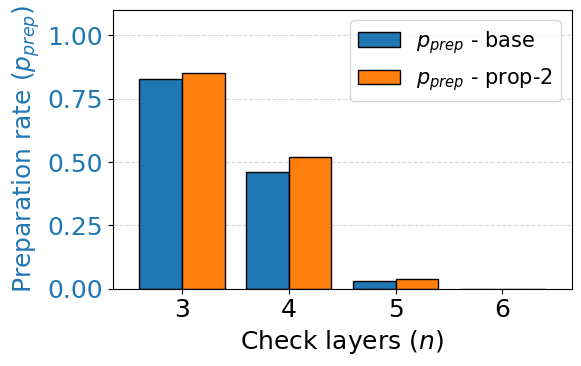

In [ ]:
n_val = 4

file_path = f"./output/STIM/qiskit/ibm_marrakesh_polar_results_json_qiskit_all_combined.csv"


# p_error_val = 0.005
p_error_val = 1
shots_val = 100

# p_error_val = 1

sim_type_val = ["normal", "m1"]
i_val = [2]
lstate_val = "x"


plot_result_decay_rate_normal(file_path, n_val, p_error_val, sim_type_val, lstate_val, i_val, shots_val, ler_ylim_min=5e-6, ler_ylim_max=1e-3) 


# Qiskit - ALL

## Pareto Plot

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from typing import List, Dict, Any


def create_figure_pareto_refined_all(
    df,
    n_values,
    lstate_values,
    i_values,
    sim_type_values,
    expected_error_targets=[1e2, 1e3, 1e4, 1e5, 1e6],
    ler_ylim=[1e-10, 1e-2],
    out_path="pareto_plot_refined.png",
    countour_shots=1e10
):
    # --- 1. Data Loading ---

    # Filter Data
    filtered_df = df[
        (df['n'].isin(n_values)) &
        (df['lstate'].isin(lstate_values)) &
        (df['p_error'] != 0.05) & 
        ( (df['p_error'] == 1) | (df['p_error'] == 0.005) ) &
        (df['i'].isin(i_values)) &
        (df['LER'] != 0) &
        (df['sim_type'].isin(sim_type_values))
    ].copy()

    # Sort for consistent line plotting (connect small i to large i)
    filtered_df = filtered_df.sort_values(by=['p_error', 'sim_type', 'i'])
    filtered_df["attempts_per_success"] = 1.0 / filtered_df["prep_rate"]

    # --- 2. Setup Plot ---
    fig, ax = plt.subplots(figsize=(9, 7))

    # --- 3. Plot Iso-Contours (Background) ---
    x_min, x_max = filtered_df["attempts_per_success"].min() * 0.85, filtered_df["attempts_per_success"].max() * 1.0
    # x_min, x_max = 0.9, 3.7
    x_vals = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    shots = countour_shots

    for t in expected_error_targets:
        ler_vals = (t / shots) * x_vals
        # Check if line is within visible Y-range to avoid clutter
        if np.any((ler_vals > ler_ylim[0]) & (ler_vals < ler_ylim[1])):
            ax.plot(x_vals, ler_vals, linestyle="--", linewidth=0.8, color="gray", alpha=0.4, zorder=1)
            
            # Inline Labeling for Contours (Cleaner than Legend)
            # Find a nice spot (e.g., near the right edge)
            y_pos_at_max = (t / shots) * x_max
            if ler_ylim[0] < y_pos_at_max < ler_ylim[1]:
                ax.text(
                    x_max, y_pos_at_max, 
                    f" {format_to_mathtext(t)} errs", 
                    fontsize=16, color="gray", va="center"
                )

    # --- 4. Plot Data & Grouping Lines ---
    
    # Create a sequential color map for 'i'
    # Normalize i values to map to colors
    norm = mcolors.Normalize(vmin=min(i_values), vmax=max(i_values))
    cmap = cm.viridis  # Sequential colormap is better for ordered data like 'i'

    # Group by p_error and sim_type to draw connecting lines
    groups = filtered_df.groupby(['hw_name', 'sim_type'])

    for (hw_name, s_type), group in groups:
        # Sort group by 'i' to ensure the line follows the iteration order
        group = group.sort_values('i')
        
        # Draw the connecting line (The "Group" visualizer)
        ax.plot(
            group["attempts_per_success"], 
            group["LER"], 
            color=LINECOLOR_MAP_PARETO.get(hw_name, 'ibm_torino'), 
            linestyle=LINESTYLE_MAP_PARETO.get(hw_name, 'ibm_torino'), 
            linewidth=1.5, 
            alpha=0.9, 
            zorder=2
        )

        # Add a single label for this p_error group
        # We place it near the last point (largest i) or first point
        if s_type == "normal":
            xytext_pos = (-10, -18)
        

            # if lstate_values[0] == "x":
            #     if hw_name == 0.1 and s_type == "m1":
            #         xytext_pos = (-10, -17)
            #     elif hw_name == 0.3 and s_type == "m1":
            #         xytext_pos = (-10, -17)
            #     elif hw_name == 0.5 and s_type == "m1":
            #         xytext_pos = (-10, -17)
            # else:
            #     if s_type == "m1":
            #         xytext_pos = (-10, -17)

            if hw_name == "all-to-all":
                p_err = format_to_mathtext(0.005)
                xytext_pos = (-20, -18)
            else:
                p_err = 1
                xytext_pos = (10, 0)

            if lstate_values[0] == "z":
                idx = -1
            else:
                idx = 0

            last_point = group.iloc[idx]
            ax.annotate(
                p_err, 
                xy=(last_point["attempts_per_success"], last_point["LER"]), # The point to label
                xytext=xytext_pos,             # Shift 10 points right, 0 points up
                textcoords="offset points", # Interpret xytext as screen pixels, not data coordinates
                fontsize=14, 
                # fontweight='bold', 
                color="#333333",
                va="center",
                zorder=10
            )

        # Plot the actual scatter points on top
        for _, row in group.iterrows():
            ipos = row["i"]
            color = COLOR_MAP_PARETO.get(ipos, 'k')
            ax.scatter(
                row["attempts_per_success"],
                row["LER"],
                s=130,
                marker=MARKER_MAP.get(s_type, 'o'),
                # color=cmap(norm(row['i'])), # Color mapped to 'i'
                color=color, # Color mapped to 'i'
                edgecolor="k",
                linewidth=0.8,
                zorder=5
            )

    # --- 5. Legends ---
    
    # Legend 1: Simulation Type (Markers)
    marker_handles = [
        mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label="prop-2") if l == "m1" 
        else mlines.Line2D([], [], color='k', marker=m, linestyle='None', markersize=12, label=l)
        for l, m in MARKER_MAP.items()
    ]
    leg1 = ax.legend(handles=marker_handles, loc="lower left", bbox_to_anchor=(0.56, 0.28), frameon=True)
    ax.add_artist(leg1)

    line_handles = [
        mlines.Line2D([], [], color=LINECOLOR_MAP_PARETO.get(l, "ibm_torino"), marker="None", linestyle=m, markersize=12, label=l) if l == "m1" 
        else mlines.Line2D([], [], color=LINECOLOR_MAP_PARETO.get(l, "ibm_torino"), marker="None", linestyle=m, markersize=12, label=l)
        for l, m in LINESTYLE_MAP_PARETO.items()
    ]
    leg2 = ax.legend(handles=line_handles, loc="lower left", bbox_to_anchor=(0.16, 0), frameon=True)
    ax.add_artist(leg2)

    # Legend 3: Iterations (Colorbar approach or discrete legend)
    # Since specific discrete 'i' values are important, we use a discrete legend
    i_handles = []
    sorted_i = sorted(i_values)
    for val in sorted_i:
        i_handles.append(mlines.Line2D([], [], color=COLOR_MAP_PARETO.get(val, 'k'), marker='o', linestyle='None', label=f"i = {val}"))
    
    ax.legend(handles=i_handles, loc="lower left", bbox_to_anchor=(0.56, 0), frameon=True)

    # --- 6. Final Styling ---
    ax.set_xscale("linear") # Or log, depending on preference
    ax.set_yscale("log")
    ax.set_ylim(ler_ylim)
    ax.set_xlim(left=x_min, right=x_max * 1.15) # Add extra space on right for labels

    ax.set_xlabel(r"Shots per successful prepared state ($1 / p_{prep}$)")
    ax.set_ylabel("Logical Error Rate (LER)")
    # ax.set_title(f"Pareto Frontier: Overhead vs LER (Shots={format_to_mathtext(shots)})", fontsize=14)
    
    ax.grid(which="major", linestyle=":", linewidth=0.7, alpha=0.7)

    info_text = "Iso-contours based on $10^{10}$ total shots"
    # Add text box to top right
    # x=0.97, y=0.97 puts it in the top right corner relative to axes axes
    # ha='right', va='top' aligns the text box anchor to its own top-right corner
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey')
    ax.text(0.97, 0.97, info_text, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()


In [ ]:
file_path = f"./output/STIM/normal/n4_result/polar_results_json_normal_n4_combined.csv"
df_ata = pd.read_csv(file_path)
df_ata["hw_name"] = "all-to-all"

hw_name = "ibm_torino"
file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
df_torino = pd.read_csv(file_path)
df_torino["hw_name"] = hw_name

hw_name = "ibm_fez"
file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
df_fez = pd.read_csv(file_path)
df_fez["hw_name"] = hw_name

hw_name = "ibm_marrakesh"
file_path = f"./output/STIM/qiskit/{hw_name}_polar_results_json_qiskit_n5_combined.csv"
df_marrakesh = pd.read_csv(file_path)
df_marrakesh["hw_name"] = hw_name

df_all = pd.concat([df_ata, df_torino, df_fez, df_marrakesh])

df_all.head()

,n,lstate,i,p_error,sim_type,shots,prep_rate,prep_rate_SEM,prep_rate_SD,LER,...,cost,cost_SEM,count_accept,count_logerror,count_undecided,count_detect_discard,total_meta_shots,detect_normal,decoding_normal,hw_name
0,3,x,2,0.0,m2,100,1.0,0.0,NaN,0.0,...,1.0,0.0,100,0.0,0,0,0,0.0,0.002917,all-to-all
1,3,x,3,0.0,m2,100,1.0,0.0,NaN,0.0,...,1.0,0.0,100,0.0,0,0,0,0.0,0.002559,all-to-all
2,3,x,4,0.0,m2,100,1.0,0.0,NaN,0.0,...,1.0,0.0,100,0.0,0,0,0,0.0,0.011575,all-to-all
3,3,x,5,0.0,m2,100,1.0,0.0,NaN,0.0,...,1.0,0.0,100,0.0,0,0,0,0.0,0.002856,all-to-all
4,3,x,6,0.0,m2,100,1.0,0.0,NaN,0.0,...,1.0,0.0,100,0.0,0,0,0,0.0,0.013048,all-to-all


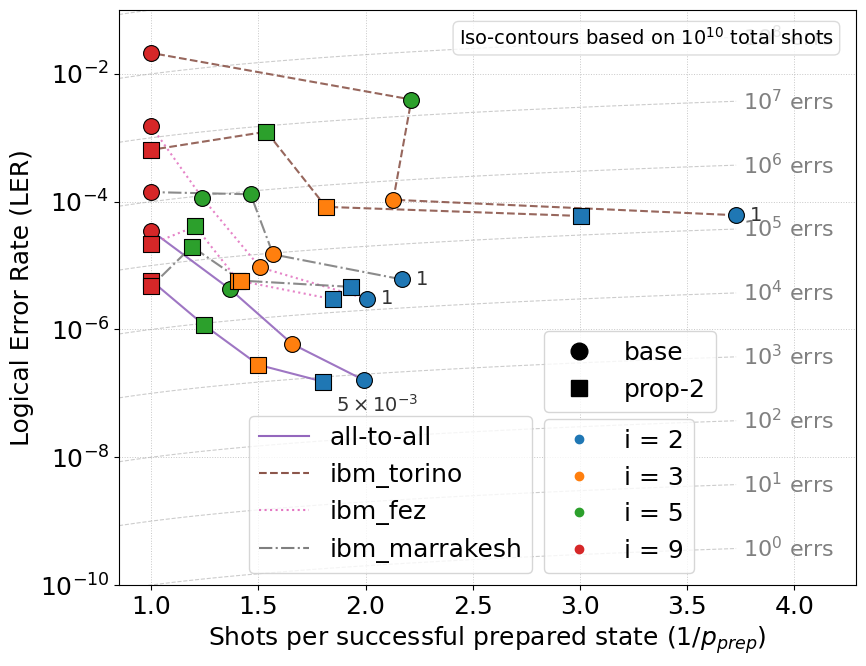

In [ ]:
expected_error_targets: List[float] = [1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
ler_ylim: List[float] = [1e-10, 1e-1]

# for z
# lstate_values = ["z"]
# i_values = [8, 12, 14, 15]

lstate_values = ["x"]
i_values = [2, 3, 5, 9]

sim_type_values = ["normal", "m1"]

# ibm_marrakesh_polar_pareto_n4_z

create_figure_pareto_refined_all(df_all, n, lstate_values, i_values, sim_type_values, expected_error_targets, ler_ylim, 
                                       out_path=f"./output/STIM/qiskit/ibm_all_polar_pareto_n{n[0]}_{lstate_values[0]}.png", countour_shots=1e10)